Okay, this is gonna be a write-up of a bunch of the different methods we've come up with to evolve the Carter Constant over time. I'll briefly describe each one, then come up with examples and show how they behave in different arenas, ideally to show off why certain ones seem to suck buckets and find out which one is least bad.

The main thrust is this: EMRICode is meant to work by evolving a particle through a series of geodesic paths. Each family of geodesics is defined by the specific energy $E$, the axial angular momentum $L_z$, and the Carter constant $C$, and the change to each of these constants is determined by the motion along the geodesic. Peters (1964) gives us a nice solid base for $\Delta E$ and $\Delta \vec{L}$ based on the quadrupole moment of the system, but it does NOT give us anything for $\Delta C$. Without an *explicit* way to get $\Delta C$, we have to find a way to approximate it reliably.

Moving forward:
- Four-position (BL coords): $x^\mu = [t, r, \theta, \phi]$
- Four-velocity (BL coords): $u^\mu = [\frac{dt}{d\tau}, \frac{dr}{d\tau}, \frac{d\theta}{d\tau}, \frac{d\phi}{d\tau}]$
- The "state": $\vec{s} = [x^\mu, u^\mu]$

## Method 1: Least Squares Approximation

Given our new values $E_f = E_o + \Delta E$ and $\vec{L}_o = \vec{L}_o + \Delta \vec{L}$, there are a limited number of states (position-velocity combinations) that work - if we assume that the best choice for this new state is the one that minimizes the change from our previous state, we can actually work *backwards* from the new state to get $\Delta C$.

Start by converting $u^\mu$ to its Zero Angular Momentum (ZAMO) tetrad form, $u^{\tilde{\mu}} = [\gamma, \gamma v^i]$. This guarantees that our true four-velocity will be normalized to satisfy the mass-shell equation $g_{\mu \nu} u^\mu u^\nu = -1$. We then assume that $\Delta E$, $\Delta \vec{L}$, and $\delta v^i$ are all small such that we can assume a linear equation $\bold{A} \vec{x} = \vec{b}$:

\begin{gather}
 \begin{bmatrix} 
 A_{11} & A_{12} & A_{13} \\
 A_{21} & A_{22} & A_{23} \\
 A_{31} & A_{32} & A_{33} \\
 A_{41} & A_{42} & A_{43} \\ 
 \end{bmatrix}
 \begin{bmatrix} 
 \delta v^{\tilde{r}} \\ 
 \delta v^{\tilde{\theta}} \\ 
 \delta v^{\tilde{\phi}} \\ 
 \end{bmatrix}
 =
 \begin{bmatrix} 
 \Delta E \\ 
 \Delta L^x \\  
 \Delta L^y \\  
 \Delta L^z \\  
 \end{bmatrix}
\end{gather}

To determine the elements of $\bold{A}$, we apply small changes $\vec{x_0} = [\epsilon, 0, 0], \vec{x_1} = [0, \epsilon, 0], \vec{x_2} = [0, 0, \epsilon]$ (where $\epsilon \approx 10^{-7}$) to the original $v^i$, then transform the new vector back to BL coordinates to get new constants $[E_{x_i}, \vec{L}_{x_i}]$; we then obtain $A_{ij} = \frac{1}{\epsilon} ([E_o, \vec{L}_o] - [E_{x_i}, \vec{L}_{x_i}])$. We solve for $\vec{x} = (\bold{A}^T \bold{A})^{-1} \bold{A}^T \vec{b}$, then calculate the new $u^\mu$. It is then trivial to calculate $C_f$.

## Method 1a: Modified Least Squares

$\bold{A}$ can be ill-conditioned, especially far away from the central body, so it can give some crazy values for dC. If instead of trying to do the least squares inversion thing ourselves, we use numpy's native linalg.lstsq() function, it behaves a little better - not exceptionally though. The problem is that, for some set of distances/positions, $E$ and $\vec{L}$ aren't all that sensitive to small changes in velocity. Sucks to suck!

## Method 2: Glampedakis derivative

In Glampedakis et al (2002), Eq. A3 provides an approximation for the Carter constant. It seems possible to take the differential of this approximation and be done with it:

\begin{gather}
C = L^2 - L_z^2 + a^2 \cos^2{\theta} (1 - E^2) \\ 
\Delta C = 2 \big( \vec{L} \cdot \Delta \vec{L} - L_z (\Delta L_z) - a^2 \cos^2{\theta} E (\Delta E) \big),
\end{gather}

but $\vec{L}$ is not well defined in Kerr space like $L^2$ is. For a best approximation, we convert $\vec{s}$ to cartesian coordinates $\vec{s_c}$ and define $\vec{L}$:

\begin{gather}
\tilde{L} = x_c^i \times u_c^i \\
\vec{L} \equiv \sqrt{L^2} \frac{\tilde{L}}{|\tilde{L}|} \\ 
\end{gather}

such that $\vec{L} \cdot \vec{L} = L^2$. Now we plug in this new value for the vector, and $\Delta \vec{L}$ comes from the Peters equations. 

## Method 2a: Modified Glampedakis derivative

Original method acts funky for some reason! However, we get better (or at least, distinct) behavior if we instead use

\begin{gather}
C = L_x^2 + L_y^2 + a^2 \cos^2{\theta} (1 - E^2) \\ 
\Delta C = 2 \big( L_x (\Delta L_x) + L_y (\Delta L_y) - a^2 \cos^2{\theta} E (\Delta E) \big).
\end{gather}

We still need to use the same method to calculate $L_x$ and $L_y$, but it seems to be a little less temperamental! We'll try stuff and see when it is and isn't crappy.

## Method 3: Effective Potential Total Differentials

Geodesic motion in the Kerr metric can be derived from the effective potentials:

\begin{gather}
P(r) = E(r^2 + a^2) - a L_z \\
D(r) = (r^2 - 2 r + a^2) \\
R(r) = [P(r)]^2 - D(r) [r^2 + (aE - L_z)^2 + C] \\
\Theta(\cos(\theta)) = C - (C + a^2 (1 - E^2) + L_z^2) \cos^2{\theta} + a^2(1 - E^2) \cos^4{\theta}
\end{gather}

At critical points, the potentials equal 0; we then rearrange both to isolate C:

\begin{gather}
C = \frac{1}{D(r_e)} P(r_e)^2 - r_e^2 - (a E - L_z)^2 \\
C = (1 - \chi_{-}^2) \bigg[a^2 (1 - E^2) + \frac{L_{z}^2}{\chi_{-}^2} \bigg] \\
r_e = \{r_p, r_a\}, \chi_{-} = \sin(\theta_{-}) \\
\end{gather}

Where we use $\chi_{\_} = \sin(\theta_{-})$ instead of the traditional $z_{\_} = \cos(\theta_{-})$ to preserve the sign of $\theta_{-}$. We then find the total differentials:

\begin{align}
\Delta C &= \frac{\delta C}{\delta E} \Delta E + \frac{\delta C}{\delta L_z} \Delta L_z + \frac{\delta C}{\delta r_e} \Delta r_e \\
\Delta C &= \frac{\delta C}{\delta E} \Delta E + \frac{\delta C}{\delta L_z} \Delta L_z + \frac{\delta C}{\delta \chi_{-}} \Delta \chi_{-} \\
\end{align}

The partial derivatives are trivial to find, and $\Delta E$ and $\Delta L_z$ are again given by Peters' equations, but $\Delta r_e$ and $\Delta \chi_{-}$ are more complex.

### Finding $\Delta \chi_{-}$

Trying to find the change in inclination exactly leads to circular logic - to find the change in $C$ we need the change in $\chi_{-}$, but to find the change in $\chi_{-}$ we need the change in $C$. Instead of freaking out about that, we take advantage of the fact that inclination is expected to change very slowly over the course of an entire inspiral, and be essentially negligble for a single orbit. We take the time derivative of $C$ and find that it is conveniently easy to isolate $\dot{\chi}_{-}$:

\begin{gather}
\dot{C} =  2 \chi_{-} \dot{\chi}_{-} \bigg[a^2 (1 - E^2) + \frac{L_{z}^2}{\chi_{-}^2} \bigg] + 
(1 - \chi_{-}^2) \bigg[-2 a^2 E \dot{E} + \frac{1}{\chi_{-}^4} (2 L_z \dot{L_z} \chi_{-}^2 - 2 L_z^2 \chi_{-} \dot{\chi}_{-})\bigg] \\
\dot{\chi}_{-} = \frac{\dot{C} + a^2 E \dot{E} (1 - \chi_{-}^2) + L_z \dot{L}_z \chi_{-} (1 - \chi_{-}^2) }{-2 \big(a^2 \chi_{-} (1 - E^2) + \frac{L_z^2}{\chi_{-}^3} \big)} \\
\end{gather}

We then assume that all of our relevant derivatives are linear on the single-orbit timescales we're working with, so it's no issue to replace all our dotted values with $\Delta$'d values. We also assume that $\Delta C \approx \Delta C_0 = \frac{\delta C}{\delta E} \Delta E + \frac{\delta C}{\delta L_z} \Delta L_z$; we plug this into our new expression for $\Delta \chi_{-}$, then plug that into the full equation.

Another way (that I haven't fully implemented):

With the same assumption $\Delta C \approx \Delta C_0 = \frac{\delta C}{\delta E} \Delta E + \frac{\delta C}{\delta L_z} \Delta L_z$; the original effective potential is quadratic in $\chi_{-}^2$, so we find
\begin{gather}
A = a^2 (1 - E^2) \\
z_{-}^2 = 1 - \chi_{-}^2 = \frac{1}{2A} \bigg( (A + C + L_z^2) \pm \sqrt{(A + C + L_z^2)^2 - 4 A C} \bigg) \\
\end{gather}

Physical values correspond to the negative branch. If we find the difference between the original value and the one after the changes are applied $(E \rightarrow E + \Delta E, L_z \rightarrow L_z + \Delta L_z, C \rightarrow C + \Delta C_0)$, we get:

\begin{align}
1 - \chi_{-o}^2 - (1 - \chi_{-f}^2) &= 1 - \chi_{-o}^2 - (1 - (\chi_{-o} + \Delta \chi_{-})^2)  \\
&=  \Delta \chi_{-}^2  + 2 \chi_{-o} (\Delta \chi_{-}) \\
&= z_{-o}^2 - z_{-f}^2 = Z \\
\Downarrow \\
\Delta \chi_{-} &= -\chi_{-o} \pm \sqrt{\chi_{-o}^2 - Z}
\end{align}


### Finding $\Delta r_e$

Finding $r_e$ is complicated by the fact that the radial potential is quartic in $r$. The two main ways I ended up doing it are:
- Point-Specific: Use the total differential of $R(r, a, E, L_z, C)$ to compute $\Delta C_0$ at a specific radius, then calculate the corresponding radius for $R(r, a, E + \Delta E, L_z + \Delta L_z, C + \Delta C_0)$ and use the difference as $\Delta r_e$
- Integration: Calculate $\Delta C = \int_{t_o}^{t_f} (\frac{dC}{dE} \frac{dE}{dt} + \frac{dC}{dL_z} \frac{dL_z}{dt}) dt$ where $\frac{dC}{dE}$ and $\frac{dC}{dL_z}$ are evaluated for each radius along $r(t)$
- Cross-point-specific? (Not implemented): Looking at one of the cells down there, it looks like point-specific might be more realistic/physical if I evaluate the stuff at one point and use that to calculate dr at a different point? Not sure




Then you do single orbit vs inc and vs radius plots for each, and maybe a multi orbit check for tent-pole type stuff? Quasi circular, zoom whirl, polar, generic strong field?

In [23]:
import MetricMathStreamline as mm
import MainLoopStreamline as ml
import OrbitPlotter as op
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import importlib
from tqdm import tqdm
importlib.reload(ml)
importlib.reload(mm)
importlib.reload(op)
import time

def all_dcons(states, a, mu, cons, ind1, ind2):
    '''
    Calculates change in characteristic orbital values from path of test particle through space 

    Parameters
    ----------
    states : N x 8 numpy array of floats
        list of state vectors - [4-position, 4-velocity] in geometric units
    a : int/float
        dimensionless spin constant of black hole, between 0 and 1 inclusive
    mu : float
        mass ratio of test particle to central body
    ind1 : int
        index value of the first entry in states relative to the master state list in clean_inspiral
    ind2 : int
        index value of the last entry in states relative to the master state list in clean_inspiral

    Returns
    -------
     4-element numpy array of floats
        change in orbital characteristics (energy, cartesian components of L) per unit mass 
    '''
    if (ind2 - ind1 - 10) > 2:
        E0, L0, C0 = cons
        states = np.array(states)
        sphere, time = states[:, 1:4], states[:, 0] - states[0,0]
        int_sphere, int_time = mm.interpolate(sphere, time, False)
        div = np.mean(np.diff(int_time))
        quad = mm.trace_ortholize_njit(int_sphere, a)
        delta = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
        coolquad = mm.traceless_quad(quad)
        dt = np.mean(np.diff(int_time))
        dt2, dt3 = mm.matrix_derive3_numba(coolquad, dt) 
        dt2 = dt2[5:-5]
        dt3 = dt3[5:-5]
        int_time = int_time[5:-5]
        levciv = np.array([[[0, 0, 0],   #Levi-civita tensor
                            [0, 0, 1],
                            [0, -1, 0]],
                           [[0, 0, -1],
                            [0, 0, 0],
                            [1, 0, 0]],
                           [[0, 1, 0],
                            [-1, 0, 0],
                            [0, 0, 0]]])
        dedt = (-1/5)*(np.einsum('ijk,ijk ->i', dt3, dt3) - (1/3)*np.einsum('ijj,ikk ->i', dt3, dt3))
        dldt = mm.compute_dldt(dt2, dt3)
        if a == 0:
            z2 = C0/(L0**2 + C0)
        else:
            A = (a**2)*(1 - E0**2)
            sig = A + L0**2 + C0
            z2 = (sig - (sig**2 - 4*A*C0)**(1/2))/(2*A)
        
        dE = mu*mu*np.sum(dedt*div)*(states[-1,0] - states[0,0])/(int_time[-1] - int_time[0])
        dLx, dLy, dLz = mu*mu*np.sum(dldt*div, axis=0)*(states[-1,0] - states[0,0])/(int_time[-1] - int_time[0])

        P = E0*(int_sphere[5:-5,0]**2 + a*a) - a*L0
        D = int_sphere[5:-5,0]*(int_sphere[5:-5,0] - 2) + a*a
        dcdt_polar = (-2*a*a*z2*E0*dedt + 2*z2*L0*dldt[:,2]/(1 - z2))*div*mu*mu
        dcdt_radial = ((2*P*(int_sphere[5:-5,0]**2 + a*a)/D - 2*a*(a*E0 - L0))*dedt + (-2*P*a/D + 2*(a*E0 - L0))*dldt[:,2])*div*mu*mu
        return np.array([dE, dLx, dLy, dLz, np.sum(dcdt_polar), np.sum(dcdt_radial)])
    else:
        return np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    
def get_dC_stuff2(a, p, e, inc, p_lower=0.0):
    skip = False
    if p < p_lower:
        skip = True
    else:
        try:
            r_start, the_start = np.random.uniform(p/(1 + e), p/(1 - e)), np.random.uniform(abs(inc), np.pi - abs(inc))
            data = ml.EMRIGenerator(a, 0.0, "rad_orbit > 3", params=[p/(1 - e**2), e, inc], pos=[0.0, r_start, the_start, 0.0], verbose=0)
            E0, L0, C0 = data["energy"][0], data["phi_momentum"][0], data["carter"][0]
            if data["plunge"] == True or data["stop"] == True:
                skip = True
        except:
            skip = True
        
    if not skip:
        # Calculate dE, dL_vec, and dC for the EPTD integrated along the orbit
        dE, dLx, dLy, dLz, dC_polar_int, dC_radial_int = all_dcons(data["raw"], a, 1e-5, [E0, L0, C0], 0, len(data["raw"]))

        # Calculate dC for LS method
        _, new_cons = mm.new_recalc_state8d([E0, L0, C0], [dE, dLx, dLy, dLz], data["raw"][-1], a)
        dC_least_squares = new_cons[-1] - C0

        # Calculate dC for MLS method   THE DIFFERENT LEAST SQUARES STUFF??
        _, new_cons = mm.new_recalc_state8d([E0, L0, C0], [dE, dLx, dLy, dLz], data["raw"][-1], a, svd=True)
        dC_mod_least_squares = new_cons[-1] - C0

        # Calculate dC for GD method
        _, new_cons = mm.new_recalc_state9l([E0, L0, C0], [dE, dLx, dLy, dLz], data["raw"][-1], a)
        dC_mod_Glamp_derv = new_cons[-1] - C0

        # Calculate dC for MGD method
        _, new_cons = mm.new_recalc_state9j([E0, L0, C0], [dE, dLx, dLy, dLz], data["raw"][-1], a)
        dC_Glamp_derv = new_cons[-1] - C0

        # Calculate z = cos(theta_min) and x = sin(theta_min)
        if a == 0:
            z2 = C0/(L0**2 + C0)
        else:
            A = (a**2)*(1 - E0**2)
            sig = A + L0**2 + C0
            z2 = (sig - (sig**2 - 4*A*C0)**(1/2))/(2*A)
        z = np.sqrt(min(1.0, np.abs(z2)))
        x2 = 1 - z2
        x = np.sign(L0) * np.sqrt(x2)

        #Calculate dC from Polar EPTD
        dC_dE = -2*a*a*z2*E0
        dC_dLz = 2*z2*L0/(1 - z2)
        dC_dx = - 2*(a*a*x*(1 - E0*E0) + L0*L0/(x**3))
        dC0 = dC_dE*dE + dC_dLz*dLz
        dx = dC0 + 2*(1 - x2)*a*a*E0*dE - 2*L0*dLz*(1 - x2)/x2
        dx /= -2*(x*(a*a*(1 - E0*E0) + L0*L0/x2) + L0*L0*(1 - x2)/(x**3))
        dC_polar = dC0 + dC_dx*dx

        #Calculate dC from Polar EPTD (explicit difference)
        dC_dE = -2*a*a*z2*E0
        dC_dLz = 2*z2*L0/(1 - z2)
        dC0 = dC_dE*dE + dC_dLz*dLz
        A2 = (a**2)*(1 - (E0 + dE)**2)
        sig2 = A2 + (L0 + dLz)**2 + C0 + dC0
        z2_2 = (sig2 - (sig2**2 - 4*A2*(C0 + dC0))**(1/2))/(2*A2)
        dx = np.sign(L0 + dLz)*np.sqrt(1 - z2_2) - x
        dC_polar_diff = dC0 + dC_dx*dx

        #Calculate dC from Radial EPTD (at potential minimum)
        poly = np.array([4*(E0**2 - 1), 3*2, 2*((a**2)*(E0**2 - 1) - L0**2 - C0), 2*((a*E0 - L0)**2 + C0)])
        r = np.real(max(np.roots(poly)))
        P, D = E0*(r*r + a*a) - a*L0, r*r - 2*r + a*a
        dC_dE = 2*P*(r*r + a*a)/D - 2*a*(a*E0 - L0)
        dC_dLz = -2*a*P/D + 2*(a*E0 - L0)
        dC0 = dC_dE*dE + dC_dLz*dLz
        dC_dr = (4*E0*r*P - P*P*(2*r - 2))/(D*D) - 2*r
        poly2 = np.array([4*((E0 + dE)**2 - 1), 3*2, 2*((a**2)*((E0 + dE)**2 - 1) - (L0 + dLz)**2 - (C0 + dC0)), 2*((a*(E0 + dE) - (L0 + dLz))**2 + (C0 + dC0))])
        dr = np.real(max(np.roots(poly2))) - r
        dC_radial_pot_min = dC0 + dC_dr*dr

        #Calculate dC from Radial EPTD (at apoapse)
        poly = np.array([(E0**2 - 1), 2, ((a**2)*(E0**2 - 1) - L0**2 - C0), 2*((a*E0 - L0)**2 + C0), -C0*(a**2)])
        r = np.real(max(np.roots(poly)))
        P, D = E0*(r*r + a*a) - a*L0, r*r - 2*r + a*a
        dC_dE = 2*P*(r*r + a*a)/D - 2*a*(a*E0 - L0)
        dC_dLz = -2*a*P/D + 2*(a*E0 - L0)
        dC0 = dC_dE*dE + dC_dLz*dLz
        dC_dr = (4*E0*r*P - P*P*(2*r - 2))/(D*D) - 2*r
        poly2 = np.array([((E0 + dE)**2 - 1), 2, ((a**2)*((E0 + dE)**2 - 1) - (L0 + dLz)**2 - (C0 + dC0)), 2*((a*(E0 + dE) - (L0 + dLz))**2 + (C0 + dC0)), -(C0 + dC0)*(a**2)])
        dr = np.real(max(np.roots(poly2))) - r
        dC_radial_apo = dC0 + dC_dr*dr

        #Calculate dC from Radial EPTD (at periapse)
        poly = np.array([(E0**2 - 1), 2, ((a**2)*(E0**2 - 1) - L0**2 - C0), 2*((a*E0 - L0)**2 + C0), -C0*(a**2)])
        r = np.sort(np.real(np.roots(poly)))[-2]
        P, D = E0*(r*r + a*a) - a*L0, r*r - 2*r + a*a
        dC_dE = 2*P*(r*r + a*a)/D - 2*a*(a*E0 - L0)
        dC_dLz = -2*a*P/D + 2*(a*E0 - L0)
        dC0 = dC_dE*dE + dC_dLz*dLz
        dC_dr = (4*E0*r*P - P*P*(2*r - 2))/(D*D) - 2*r
        poly2 = np.array([((E0 + dE)**2 - 1), 2, ((a**2)*((E0 + dE)**2 - 1) - (L0 + dLz)**2 - (C0 + dC0)), 2*((a*(E0 + dE) - (L0 + dLz))**2 + (C0 + dC0)), -(C0 + dC0)*(a**2)])
        dr = np.sort(np.real(np.roots(poly)))[-2] - r
        dC_radial_peri = dC0 + dC_dr*dr

        #Calculate dC from Radial EPTD (at semilatus rectum)
        poly = np.array([(E0**2 - 1), 2, ((a**2)*(E0**2 - 1) - L0**2 - C0), 2*((a*E0 - L0)**2 + C0), -C0*(a**2)])
        rp, ra = np.sort(np.real(np.roots(poly)))[-2:]
        r = 2 * rp * ra / (rp + ra)
        P, D = E0*(r*r + a*a) - a*L0, r*r - 2*r + a*a
        dC_dE = 2*P*(r*r + a*a)/D - 2*a*(a*E0 - L0)
        dC_dLz = -2*a*P/D + 2*(a*E0 - L0)
        dC0 = dC_dE*dE + dC_dLz*dLz
        dC_dr = (4*E0*r*P - P*P*(2*r - 2))/(D*D) - 2*r
        poly2 = np.array([((E0 + dE)**2 - 1), 2, ((a**2)*((E0 + dE)**2 - 1) - (L0 + dLz)**2 - (C0 + dC0)), 2*((a*(E0 + dE) - (L0 + dLz))**2 + (C0 + dC0)), -(C0 + dC0)*(a**2)])
        rp, ra = np.sort(np.real(np.roots(poly2)))[-2:]
        r2 = 2 * rp * ra / (rp + ra)
        dr = r2 - r
        dC_radial_semilat = dC0 + dC_dr*dr

        del data
        return [E0, L0, C0,                 # initial constants (0-2)
                dE, dLx, dLy, dLz,          # changes calculated from Peters (1964)  (3 - 6)
                dC_least_squares,           # 7
                dC_mod_least_squares,       # 8
                dC_Glamp_derv,              # 9
                dC_mod_Glamp_derv,          # 10
                dC_polar,                   # 11
                dC_polar_diff,              # 12
                dC_polar_int,               # 13
                dC_radial_pot_min,          # 14
                dC_radial_apo,              # 15
                dC_radial_peri,             # 16
                dC_radial_semilat,          # 17
                dC_radial_int]              # 18
    else:
        return np.nan*np.arange(19)

big_dict = {}
incs = np.linspace(np.pi/2, -np.pi/2)
for a in [0.7]: #[0.1, 0.3, 0.5, 0.7, 0.9]:
    p_lower = []
    for x in incs:
        p_sep, e_sep, _ = mm.get_sep_inc(a, x, mult=5)
        p_lower.append(p_sep[op.get_index(e_sep, e)])
    print(np.array(p_lower))
    for e in [0.1]: #[0.9, 0.5, 0.1, 1e-4]:
        print(a, e)
        if (a, e) in big_dict.keys():
            continue
        p_pro, e_pro, _ = mm.get_sep_cosi(a, 1)
        p_ret, e_ret, _ = mm.get_sep_cosi(a, -1)

        tiny_p = np.ceil(p_pro[op.get_index(e_pro, e)]*10)/10
        small_p = np.ceil(p_ret[op.get_index(e_ret, e)]*10)/10

        # Angular data
        very_strong = np.array([get_dC_stuff2(a, tiny_p*0.75 + small_p*0.25, e, incs[i], p_lower[i]) for i in range(len(incs))])
        mid_strong  = np.array([get_dC_stuff2(a, tiny_p*0.35 + small_p*0.65, e, incs[i], p_lower[i]) for i in range(len(incs))])
        low_strong  = np.array([get_dC_stuff2(a, small_p, e, incs[i], p_lower[i]) for i in range(len(incs))])
        intermed    = np.array([get_dC_stuff2(a, 1.5*(tiny_p + small_p), e, incs[i], p_lower[i]) for i in range(len(incs))])
        weak        = np.array([get_dC_stuff2(a, 5*(tiny_p + small_p), e, incs[i], p_lower[i]) for i in range(len(incs))])
        very_weak   = np.array([get_dC_stuff2(a, 10*(tiny_p + small_p), e, incs[i], p_lower[i]) for i in range(len(incs))])

        # Radial data
        ps = np.linspace(tiny_p*0.75 + small_p*0.25, 10*(tiny_p + small_p))
        p_sep, e_sep, r = mm.get_sep_inc(a, np.pi/2, mult=5)
        pro_eq  = np.array([get_dC_stuff2(a, p, e, np.pi/2, p_sep[op.get_index(e_sep, e)]) for p in ps])
        p_sep, e_sep, r = mm.get_sep_inc(a, np.pi/4, mult=5)
        pro_inc = np.array([get_dC_stuff2(a, p, e, np.pi/4, p_sep[op.get_index(e_sep, e)]) for p in ps])
        p_sep, e_sep, r = mm.get_sep_inc(a, 0.5*np.pi/180, mult=5)
        pro_np  = np.array([get_dC_stuff2(a, p, e, 0.5*np.pi/180, p_sep[op.get_index(e_sep, e)]) for p in ps])
        p_sep, e_sep, r = mm.get_sep_inc(a, -0.5*np.pi/180, mult=5)
        ret_np  = np.array([get_dC_stuff2(a, p, e, -0.5*np.pi/180, p_sep[op.get_index(e_sep, e)]) for p in ps])
        p_sep, e_sep, r = mm.get_sep_inc(a, -np.pi/4, mult=5)
        ret_inc = np.array([get_dC_stuff2(a, p, e, -np.pi/4, p_sep[op.get_index(e_sep, e)]) for p in ps])
        p_sep, e_sep, r = mm.get_sep_inc(a, -np.pi/2, mult=5)
        ret_eq  = np.array([get_dC_stuff2(a, p, e, -np.pi/2, p_sep[op.get_index(e_sep, e)]) for p in ps])

        hold_dict = {"Angular": [incs, {"Very Weak Field":      [10*(tiny_p + small_p), very_weak],
                                        "Weak Field":           [5*(tiny_p + small_p),  weak],
                                        "Intermediate Field":   [1.5*(tiny_p + small_p), intermed],
                                        "Shallow Strong Field": [small_p, low_strong],
                                        "Medium Strong Field":  [tiny_p*0.35 + small_p*0.65, mid_strong],
                                        "Deep Strong Field":    [tiny_p*0.75 + small_p*0.25, very_strong]
                                       }
                                ],
                     "Radial":  [ps ,  {"Prograde Equatorial":   [np.pi/2, pro_eq],
                                        "Prograde Inclined":     [np.pi/4, pro_inc],
                                        "Prograde Near Polar":   [0.5*np.pi/180, pro_np],
                                        "Retrograde Near Polar": [-0.5*np.pi/180, ret_np],
                                        "Retrograde Inclined":   [-np.pi/4, ret_inc],
                                        "Retrograde Equatorial": [-np.pi/2, ret_eq]
                                       }
                                ],
                    }
        
        big_dict[a, e] = hold_dict
        print(f"Dict {a}, {e} done!")
        del hold_dict



[3.51300372 3.51250031 3.52442947 3.54393448 3.57634409 3.60945446
 3.6555826  3.7088883  3.76736014 3.84533105 3.9185851  4.00842945
 4.10664268 4.20854779 4.32290735 4.44739502 4.57629899 4.70425905
 4.85271816 4.99790585 5.14251453 5.30193681 5.45785318 5.62369171
 5.78531559 5.94811198 6.11086977 6.27240531 6.43156726 6.58496797
 6.74024453 6.89916911 7.0393717  7.18307277 7.32620847 7.4550003
 7.57441606 7.70346273 7.79986484 7.9021135  7.99421537 8.08635308
 8.16719691 8.23021535 8.28184561 8.33366432 8.35669033 8.3943091
 8.40127722 8.41071592]
0.7 0.1
Dict 0.7, 0.1 done!


In [5]:
import MetricMathStreamline as mm
import MainLoopStreamline as ml
import OrbitPlotter as op
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import importlib
from tqdm import tqdm
importlib.reload(ml)
importlib.reload(mm)
importlib.reload(op)
import time

a, e = 0.7, 0.1
ps = np.linspace(2.3, 9.0, 50)
incs = np.linspace(-np.pi/2, np.pi/2, 50)
PS, INCS = np.meshgrid(ps, incs)
CONS = np.zeros((3, len(incs), len(ps)))
DERVS = np.zeros((4, len(incs), len(ps)))

for inc in range(len(incs)):
    p_sep, e_sep, r = mm.get_sep_inc(a, incs[inc], mult=5)
    p_ix = op.get_index(e_sep, e)
    print(100*inc/len(incs))
    for p in range(len(ps)):
        #print(ps[p], p_sep[p_ix])
        if ps[p] < p_sep[p_ix]:
            CONS[:, inc, p]  = np.nan * np.arange(3)
            DERVS[:, inc, p] = np.nan * np.arange(4)
        else:
            r_start, the_start = np.random.uniform(ps[p]/(1 + e), ps[p]/(1 - e)), np.random.uniform(abs(incs[inc]), np.pi - abs(incs[inc]))
            try:
                data = ml.EMRIGenerator(a, 0.0, "rad_orbit > 3", params=[ps[p]/(1 - e**2), e, incs[inc]], pos=[0.0, r_start, the_start, 0.0], verbose=0)
                if (data["plunge"] or data["stop"]) or (data["unbind"]):
                    CONS[:, inc, p]  = np.nan * np.arange(3)
                    DERVS[:, inc, p] = np.nan * np.arange(4)
                else:
                    CONS[:, inc, p] = data["energy"][0], data["phi_momentum"][0], data["carter"][0]
                    DERVS[:, inc, p] = mm.peters_integrate6_6_4(data["raw"], a, 1e-5, 0, 100)
                del data
            except:
                CONS[:, inc, p]  = np.nan * np.arange(3)
                DERVS[:, inc, p] = np.nan * np.arange(4)
        


#Original was 28m 16.4s
#Shortened to 16m 58.0s

0.0
2.0
4.0
6.0
8.0
10.0
12.0
14.0
16.0
18.0
20.0
22.0
24.0
26.0
28.0
30.0
32.0
34.0
36.0
38.0
40.0
42.0
44.0
46.0
48.0
50.0
52.0
54.0
56.0
58.0
60.0
62.0
64.0
66.0
68.0
70.0
72.0
74.0
76.0
78.0
80.0
82.0
84.0
86.0
88.0
90.0
92.0
94.0
96.0
98.0


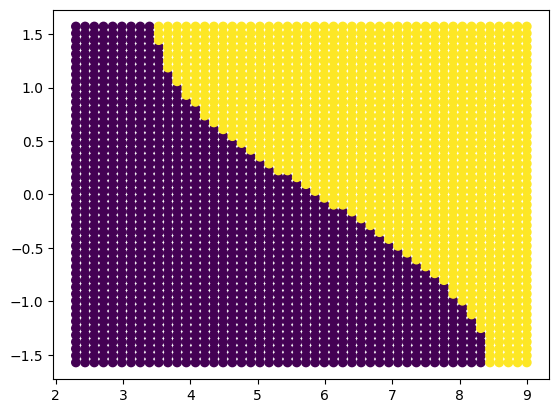

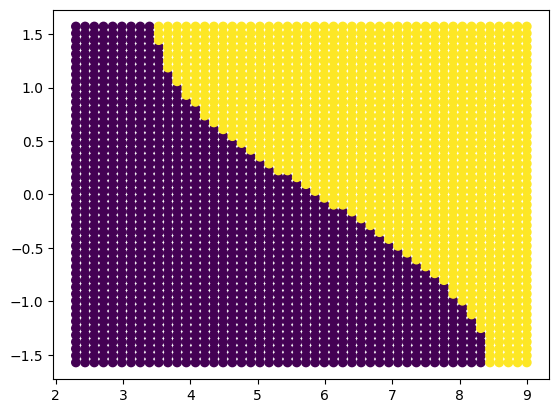

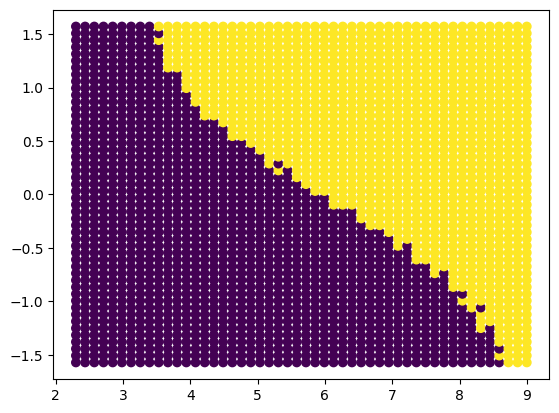

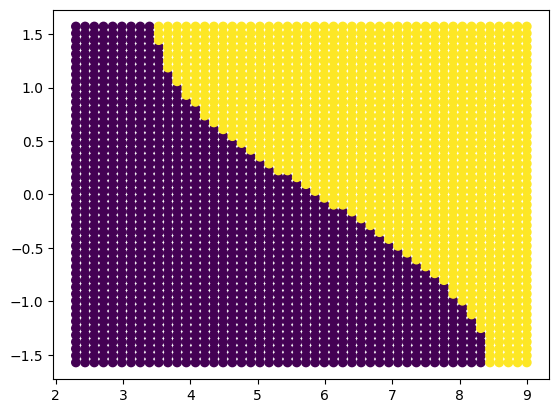

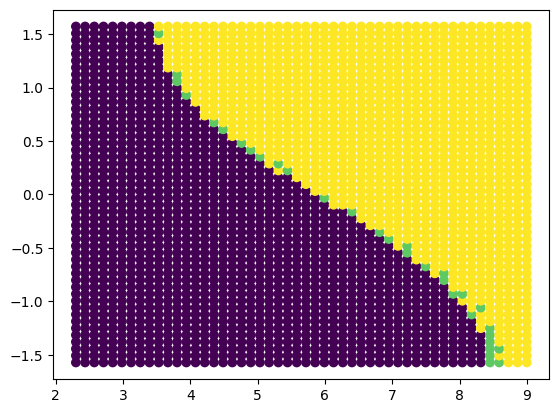

[0.0, 0.0, 0.0, 0.06716847735112425, 0.0672736491133535, 0.06740253303490373, 0.06755329675133803, 0.2675910954061468, 0.26811536715550915, 0.2687261458564234, 0.595481508089051, 0.5964862352549405, 0.597697801797435, 0.5991002747920342, 1.0447889419879224, 1.0466616228369239, 1.0488921103543187, 1.0514529183530186, 1.6007352975491298, 1.6051093553812374, 1.6082009017185328, 1.611832262794834, 1.6159621161305746, 2.2571714327892374, 2.2602102779072166, 2.2641277873816805, 2.268853329991483, 2.2743236767665174, 2.2804820548021607, 2.9970852790849323, 3.001743785307438, 3.0075384792831805, 3.0143785030120047, 3.0221824728775215, 3.030877274452904, 3.7991412794409496, 3.8112345970954338, 3.8194420352498524, 3.8289372859700874, 3.839620663335227, 3.851402554072222, 4.648457816029026, 4.6542458186352285, 4.66200086752446, 4.671558821083241, 4.682773374665333, 4.695513698721304, 4.709662442719368, 4.725114040419061, 5.541035466361242, 5.55192842264775, 5.564886848950146, 5.579744368398205, 5

In [8]:
dots = np.zeros((4, len(CONS[0]), len(CONS[0][0])))
for i in range(len(dots[0])):
    for j in range(len(dots[0][0])):
        E, L, C = CONS[:, i, j]
        if np.isnan(E):
            continue
        try:
            p_sep, e_sep, r, E_sep, L_sep, C_sep, r_out, E_out, L_out, C_out = mm.get_sep_cosi(a, L/np.sqrt(C + L**2), getELC=True, mult=5)
        except:
            continue
        E_ix = op.get_index(L_out, L)
        if np.sum(E >= E_out[E_ix-1: E_ix+2]):
            dots[0, i, j] += 1
        L_ix = op.get_index(E_sep, E)
        if np.sum(abs(L) >= np.abs(L_sep[L_ix-1: L_ix+2])):
            dots[1, i, j] += 1
        if abs(L) >= abs(L_sep[L_ix]):
            dots[2, i, j] += 1


#dots = np.zeros_like(CONS2[0])
for i in range(len(dots[2])):
    for j in range(len(dots[2][0])):
        p_sep, e_sep, r = mm.get_sep_inc(a, INCS[i, j], mult=5)
        p_ix = op.get_index(e_sep, e)
        #if np.sum(PS[i, j] >= p_sep[p_ix - 1: p_ix + 2]):
        #    dots[2, i, j] += 1
        if PS[i, j] >= p_sep[p_ix]:
            dots[3, i, j] = True

for i in range(4):
    plt.scatter(PS, INCS, c=dots[i])
    plt.show()

plt.scatter(PS, INCS, c=np.sum(dots, axis=0))
plt.show()

mask = np.sum(dots, axis=0)%3 != 0

print("[" + ", ".join([str(thing) for thing in CONS[2, :,:][mask] if not np.isnan(thing)]) + "]")


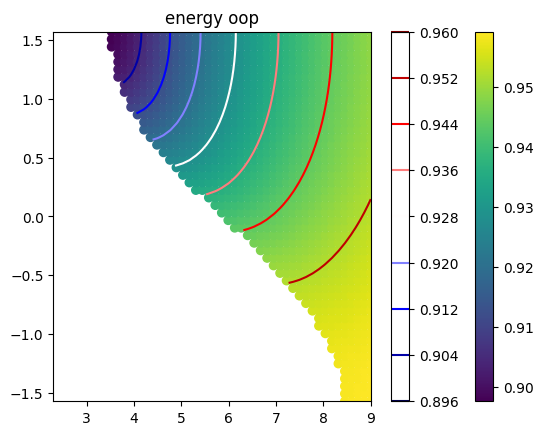

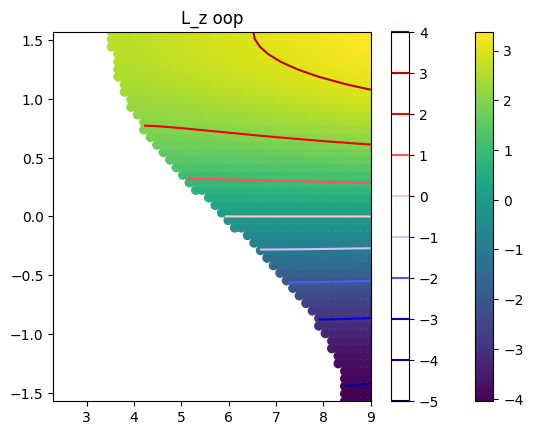

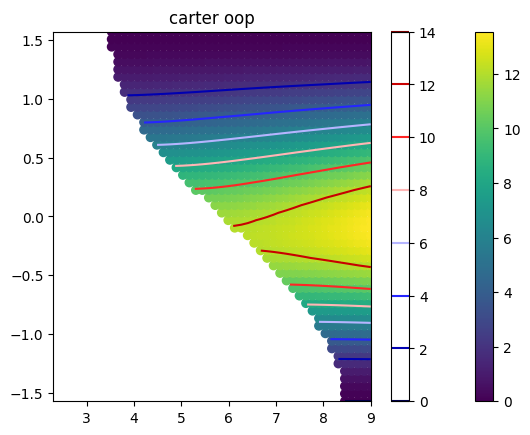

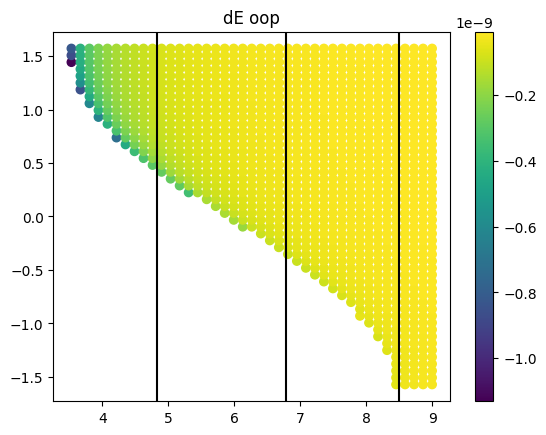

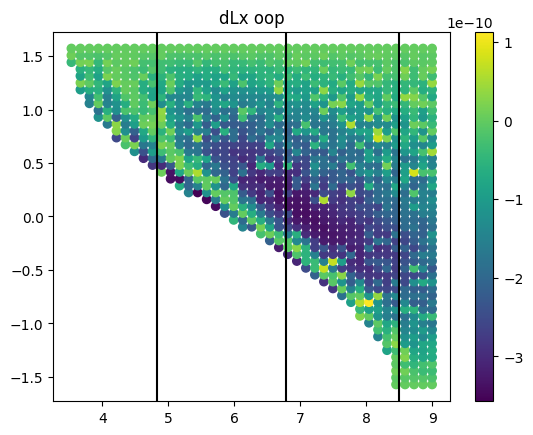

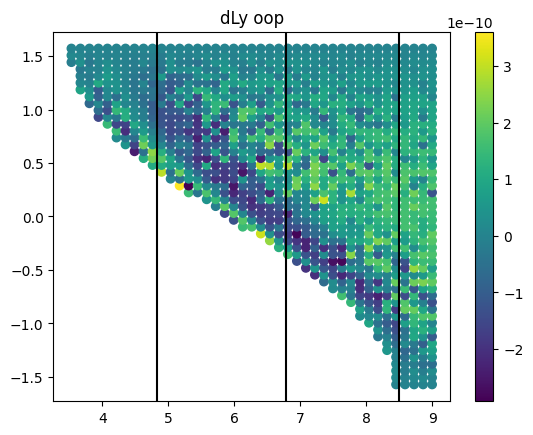

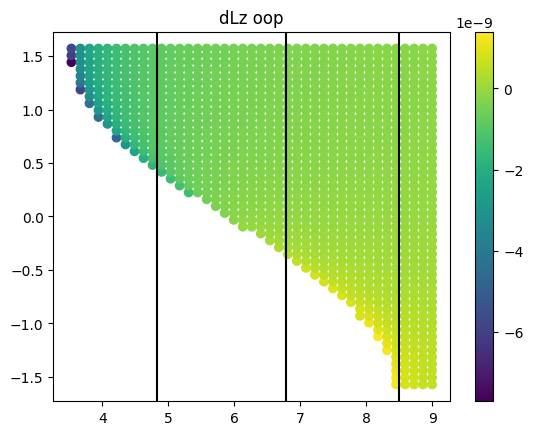

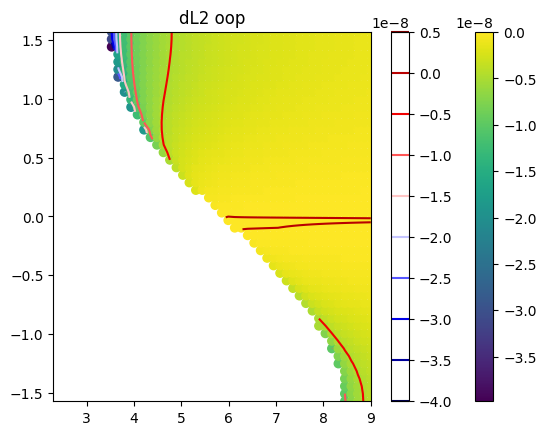

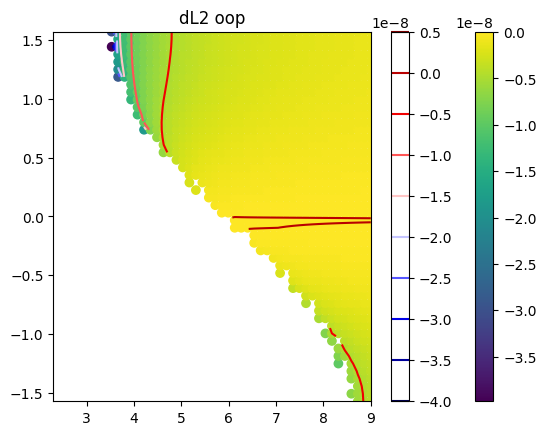

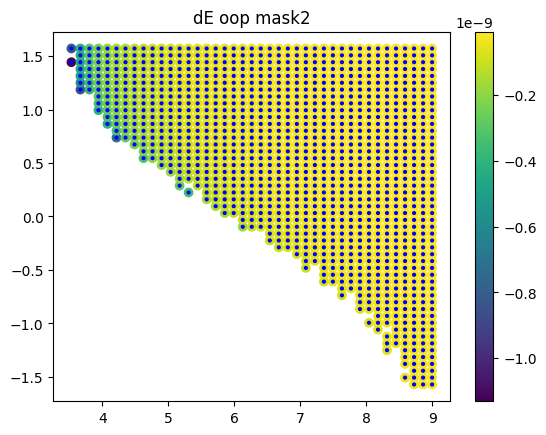

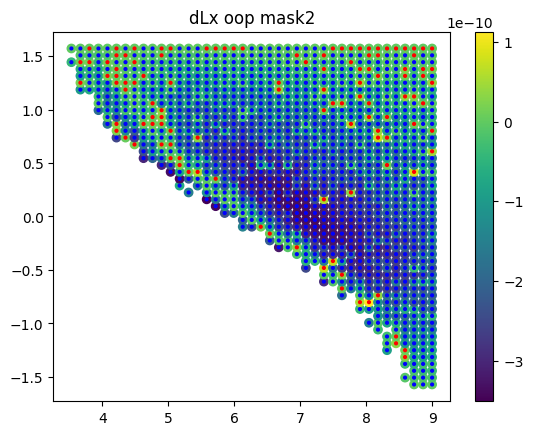

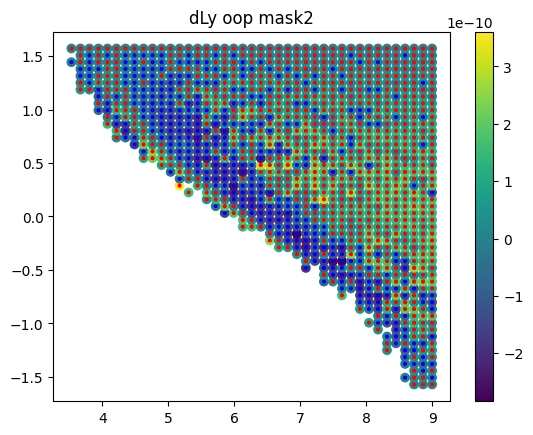

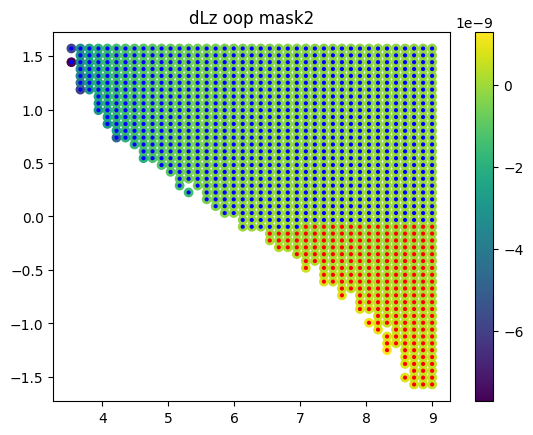

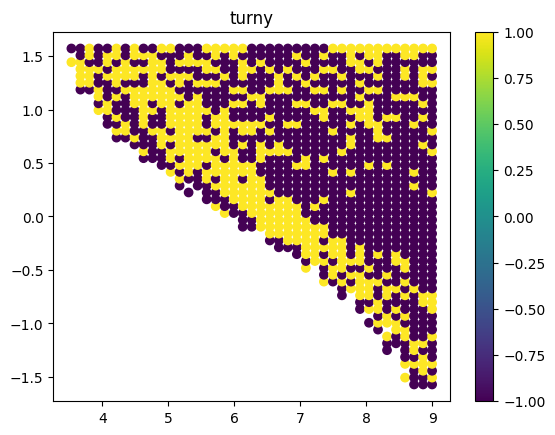

In [9]:
bound_ps = np.ones_like(incs)
for i in range(len(incs)):
    p_list, e_list, _ = mm.get_sep_inc(a, incs[i])
    bound_ps[i] = p_list[op.get_index(e_list, e)]/(1 + e)

mask = CONS[0] < 1
CONS2 = CONS.copy()
for i in range(3):
    CONS2[i] = np.where(mask, CONS[i], np.nan)

titles = ["energy", "L_z", "carter"]
for i in range(3):
    
    #plt.figure(figsize=(8,8))
    #plt.imshow(CONS2[i, :, :], extent=[ps[0], ps[-1], incs[0], incs[-1]], origin="lower")
    plt.scatter(PS, INCS, c=CONS2[i,:,:])
    plt.colorbar()
    plt.contour(PS, INCS, CONS2[i, :, :], cmap="seismic")
    plt.colorbar()
    #plt.axvline(4.825, c="k")
    #plt.axvline(6.785, c="k")
    #plt.axvline(8.5, c="k")
    #plt.plot(bound_ps, incs, c="k")
    plt.title(titles[i] + " oop")
    
    plt.show()

titles = ["dE", "dLx", "dLy", "dLz"]
for i in range(4):
    
    #plt.figure(figsize=(8,8))
    #plt.imshow(CONS[i, :, :], extent=[incs[0], incs[-1], ps[0], ps[-1]], origin="lower")
    plt.scatter(PS, INCS, c=DERVS[i,:,:])
    plt.colorbar()
    #plt.axvline(3.3931284701816304, c="k")
    #plt.axvline(8.142965464834315, c="k")
    plt.axvline(4.825, c="k")
    plt.axvline(6.785, c="k")
    plt.axvline(8.5, c="k")
    #plt.plot(bound_ps, incs, c="k")
    #plt.contour(PS, INCS, DERVS[i, :, :], cmap="seismic")
    #plt.colorbar()
    plt.title(titles[i] + " oop")
    
    plt.show()

plt.scatter(PS, INCS, c=2 * DERVS[3,:,:] * CONS2[1,:,:])
plt.colorbar()
plt.contour(PS, INCS, 2 * DERVS[3,:,:] * CONS2[1,:,:], cmap="seismic")
plt.colorbar()
#plt.axvline(4.825, c="k")
#plt.axvline(6.785, c="k")
#plt.axvline(8.5, c="k")
#plt.plot(bound_ps, incs, c="k")
plt.title("dL2 oop")

plt.show()

mask2 = np.where(dots[2], 1, np.nan)

plt.scatter(PS, INCS, c=2 * DERVS[3,:,:] * CONS2[1,:,:] * mask2)
plt.colorbar()
plt.contour(PS, INCS, 2 * DERVS[3,:,:] * CONS2[1,:,:] * mask2, cmap="seismic")
plt.colorbar()
#plt.axvline(4.825, c="k")
#plt.axvline(6.785, c="k")
#plt.axvline(8.5, c="k")
#plt.plot(bound_ps, incs, c="k")
plt.title("dL2 oop")

plt.show()

for i in range(4):
    
    #plt.figure(figsize=(8,8))
    #plt.imshow(CONS[i, :, :], extent=[incs[0], incs[-1], ps[0], ps[-1]], origin="lower")
    plt.scatter(PS, INCS, c=DERVS[i,:,:] * mask2)
    plt.colorbar()
    plt.scatter(PS, INCS, c=np.sign(DERVS[i,:,:] * mask2), s=4, cmap="bwr")
    #plt.axvline(3.3931284701816304, c="k")
    #plt.axvline(8.142965464834315, c="k")
    #plt.axvline(4.825, c="k")
    #plt.axvline(6.785, c="k")
    #plt.axvline(8.5, c="k")
    #plt.plot(bound_ps, incs, c="k")
    #plt.contour(PS, INCS, DERVS[i, :, :], cmap="seismic")
    #plt.colorbar()
    plt.title(titles[i] + " oop mask2")
    
    plt.show()

plt.scatter(PS, INCS, c = np.sign(DERVS[1,:,:] * DERVS[2,:,:] * mask2))
plt.colorbar()
#plt.contour(PS, INCS, np.sign(DERVS[1,:,:] * DERVS[2,:,:] * mask2), cmap="seismic")
#plt.colorbar()
#plt.axvline(4.825, c="k")
#plt.axvline(6.785, c="k")
#plt.axvline(8.5, c="k")
#plt.plot(bound_ps, incs, c="k")
plt.title("turny")

plt.show()

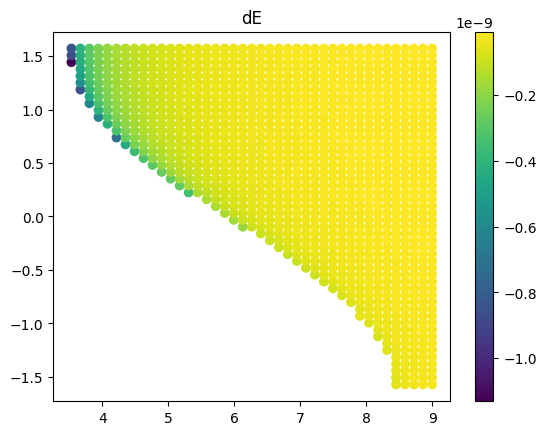

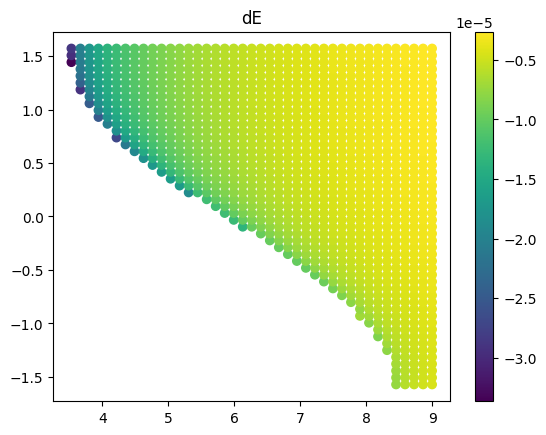

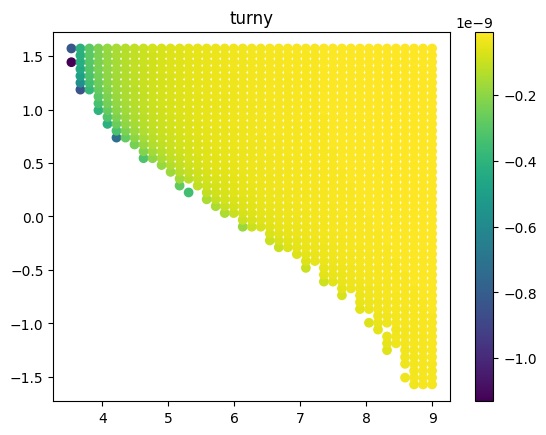

In [12]:
plt.scatter(PS, INCS, c = DERVS[0,:,:])
plt.colorbar()
#plt.contour(PS, INCS, np.sign(DERVS[1,:,:] * DERVS[2,:,:] * mask2), cmap="seismic")
#plt.colorbar()
#plt.axvline(4.825, c="k")
#plt.axvline(6.785, c="k")
#plt.axvline(8.5, c="k")
#plt.plot(bound_ps, incs, c="k")
plt.title("dE")

plt.show()

plt.scatter(PS, INCS, c = np.sign(DERVS[0,:,:])*np.sqrt(np.abs(DERVS[0,:,:])))
plt.colorbar()
#plt.contour(PS, INCS, np.sign(DERVS[1,:,:] * DERVS[2,:,:] * mask2), cmap="seismic")
#plt.colorbar()
#plt.axvline(4.825, c="k")
#plt.axvline(6.785, c="k")
#plt.axvline(8.5, c="k")
#plt.plot(bound_ps, incs, c="k")
plt.title("dE")

plt.show()

plt.scatter(PS, INCS, c = DERVS[0,:,:]* (np.where(np.sum(dots, axis=0)%3, 1, np.nan)))
plt.colorbar()
#plt.contour(PS, INCS, np.sign(DERVS[1,:,:] * DERVS[2,:,:] * mask2), cmap="seismic")
#plt.colorbar()
#plt.axvline(4.825, c="k")
#plt.axvline(6.785, c="k")
#plt.axvline(8.5, c="k")
#plt.plot(bound_ps, incs, c="k")
plt.title("turny")

plt.show()

In [446]:
a, e = 0.9, 0.9
for v in list(big_dict[a, e]["Angular"][1].keys()):
    E, L, C = big_dict[a, e]["Angular"][1][v][1][:, 0], big_dict[a, e]["Angular"][1][v][1][:, 1], big_dict[a, e]["Angular"][1][v][1][:, 2]
    dE, dL = big_dict[a, e]["Angular"][1][v][1][:, 3], big_dict[a, e]["Angular"][1][v][1][:, 6]
    incs = big_dict[a, e]["Angular"][0]
    z = np.cos(incs)
    z2 = z * z
    x2 = 1 - z2
    x = np.sqrt(x2) * np.sign(L)
    a2 = a * a
    dC_dE = -2 * a2 * z2 * E
    dC_dL = 2 * z2 * L / (1 - z2)

    dC0 = dC_dE*dE + dC_dL*dL
    dx1 = dC0 + 2*(1 - x2)*a*a*E*dE - 2*L*dL*(1 - x2)/x2
    dx1 /= -2*(x*(a*a*(1 - E*E) + L*L/x2) + L*L*(1 - x2)/(x**3))

    dx1_2 = -(0.5*dC0*x2*x + a2*E*dE*x2*x*(1 - x2) - L*dL*x*(1 - x2))
    dx1_2 /= (a2*x2*x2*(1 - E*E) + L*L)

    hold = (1 - ((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2) - np.sqrt((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2)**2 - 4*a2*(1 - (E + dE)**2)*(C + dC0)))/(2 * a2*(1 - (E + dE)**2)))
    dx23_2 = -x + np.sign(x)*np.sqrt(hold)

    org = ((a2*(1 - E*E) + C + L*L) - np.sqrt((a2*(1 - E*E) + C + L*L)**2 - 4*a2*(1 - E*E)*C ))/(2 * a2*(1 - E*E))
    new = ((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2) - np.sqrt((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2)**2 - 4*a2*(1 - (E + dE)**2)*(C + dC0)))/(2 * a2*(1 - (E + dE)**2))
    Z = org - new
    dx45_2 = np.sign(L + dL)*np.sqrt(1 - new) - x
    
    print(f"{v: ^30}: {np.sqrt(np.nanmean(dx1**2)):.4e}, {np.sqrt(np.nanmean(dx1_2**2)):.4e}, {np.sqrt(np.nanmean(dx23_2**2)):.4e}, {np.sqrt(np.nanmean(dx45_2**2)):.4e}")

       Very Weak Field        : 8.8122e-31, 1.5791e-30, 2.2259e-11, 2.2259e-11
          Weak Field          : 6.1122e-30, 7.2384e-30, 1.7330e-12, 1.7330e-12
      Intermediate Field      : 1.1847e-28, 1.2307e-28, 3.8986e-13, 3.8986e-13
     Shallow Strong Field     : 8.6915e-28, 9.8118e-28, 1.1086e-13, 1.1086e-13
     Medium Strong Field      : 1.2160e-27, 1.6803e-27, 3.5270e-14, 3.5270e-14
      Deep Strong Field       : 5.9864e-27, 1.2224e-26, 6.0360e-15, 6.0360e-15


Shallow Strong Field: p = 8.5


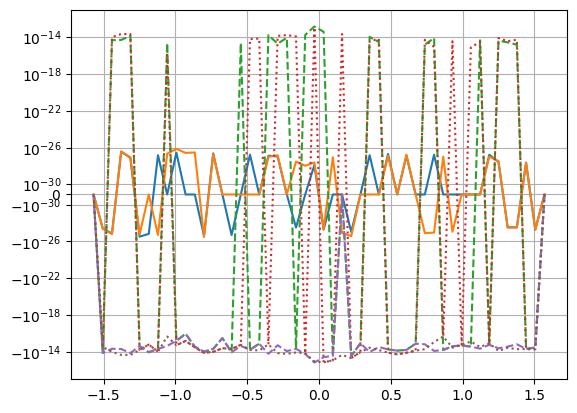

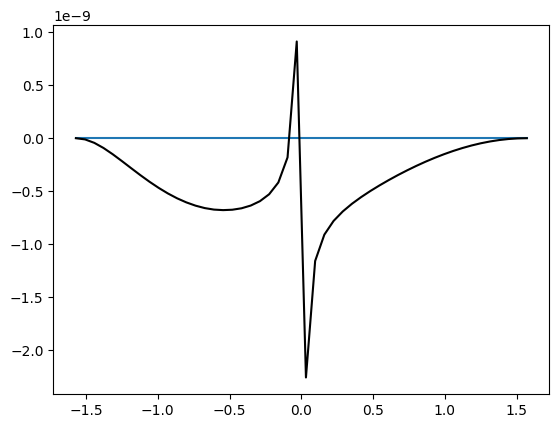

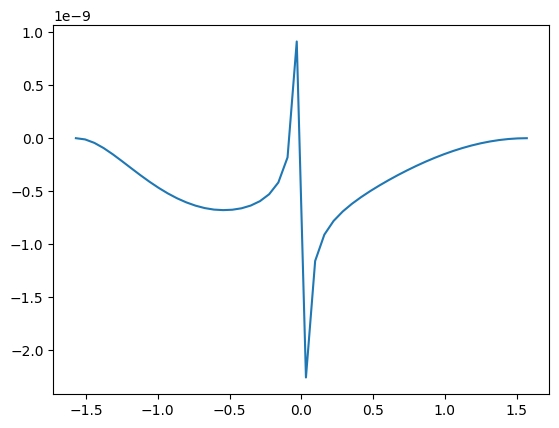

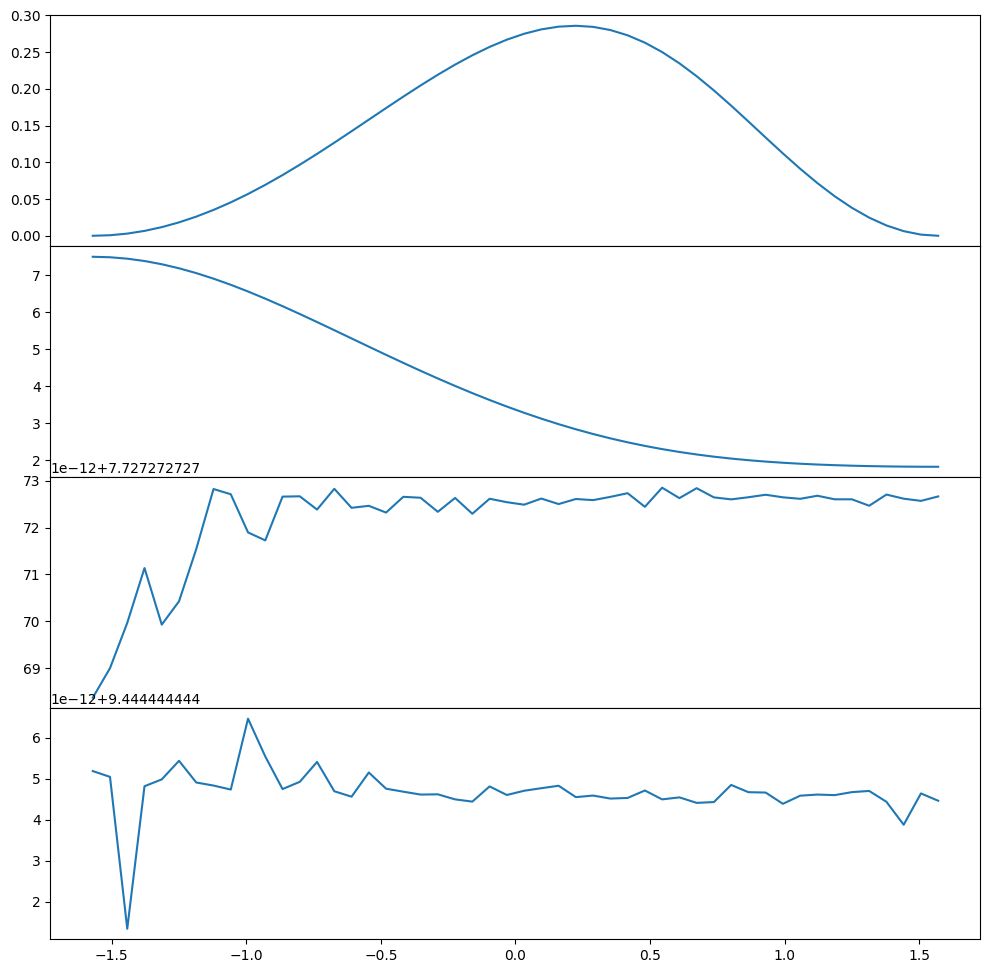

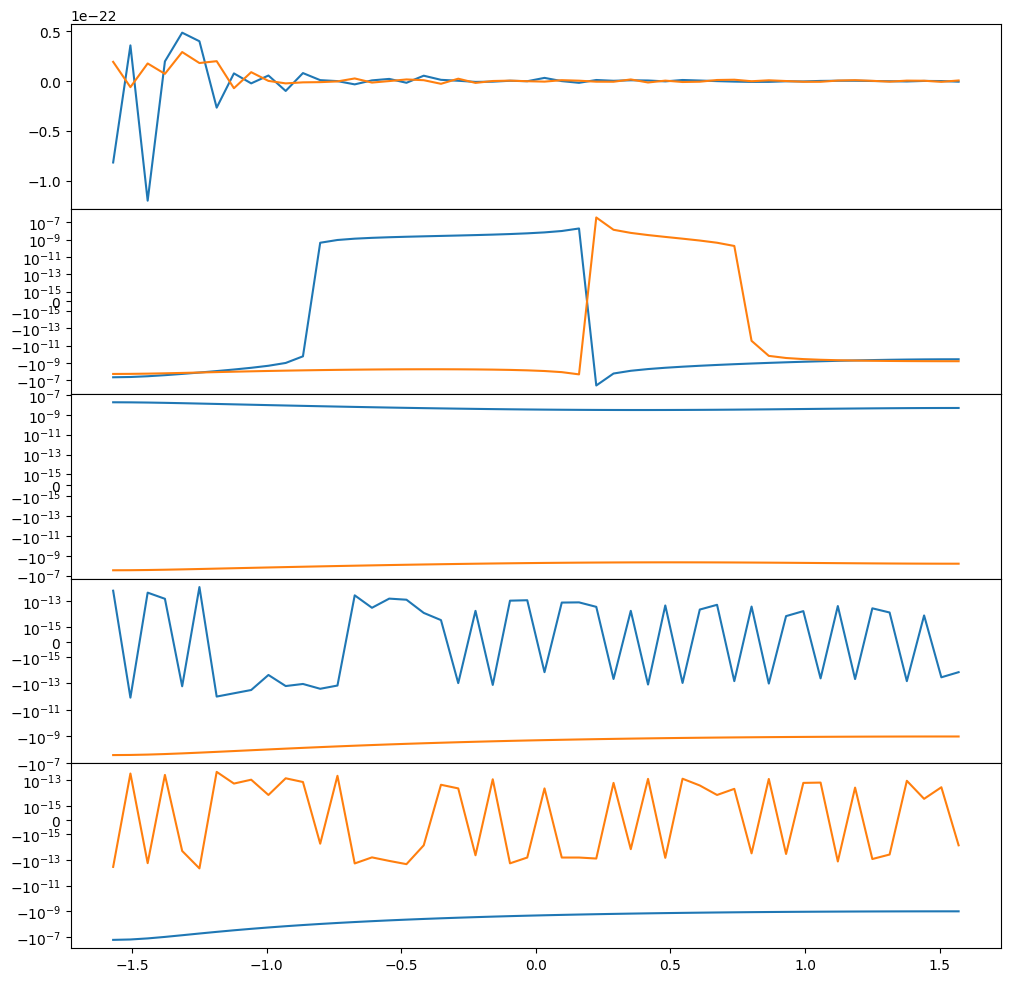

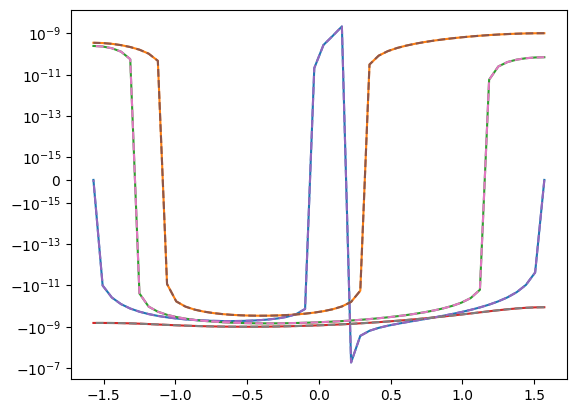

In [ ]:
a, e = 0.7, 0.1
v = np.random.choice(list(big_dict[a, e]["Angular"][1].keys()))
#v = "Deep Strong Field"
print(f"{v}: p = {big_dict[a, e]["Angular"][1][v][0]}")
E, L, C = big_dict[a, e]["Angular"][1][v][1][:, 0], big_dict[a, e]["Angular"][1][v][1][:, 1], big_dict[a, e]["Angular"][1][v][1][:, 2]
dE, dL = big_dict[a, e]["Angular"][1][v][1][:, 3], big_dict[a, e]["Angular"][1][v][1][:, 6]
incs = big_dict[a, e]["Angular"][0]
z = np.cos(incs)
z2 = z * z
x2 = 1 - z2
x = np.sqrt(x2) * np.sign(L)
a2 = a * a
dC_dE = -2 * a2 * z2 * E
dC_dL = 2 * z2 * L / (1 - z2)

dC0 = dC_dE*dE + dC_dL*dL
dx1 = dC0 + 2*(1 - x2)*a*a*E*dE - 2*L*dL*(1 - x2)/x2
dx1 /= -2*(x*(a*a*(1 - E*E) + L*L/x2) + L*L*(1 - x2)/(x**3))

dx1_2 = -(0.5*dC0*x2*x + a2*E*dE*x2*x*(1 - x2) - L*dL*x*(1 - x2))
dx1_2 /= (a2*x2*x2*(1 - E*E) + L*L)

hold = (1 - ((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2) - np.sqrt((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2)**2 - 4*a2*(1 - (E + dE)**2)*(C + dC0)))/(2 * a2*(1 - (E + dE)**2)))
dx2 = -x + np.sqrt(hold)
dx3 = -x - np.sqrt(hold)
dx23 = np.where(L >= 0, dx2, dx3)
dx23_2 = -x + np.sign(x)*np.sqrt(hold)


org = ((a2*(1 - E*E) + C + L*L) - np.sqrt((a2*(1 - E*E) + C + L*L)**2 - 4*a2*(1 - E*E)*C ))/(2 * a2*(1 - E*E))
new = ((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2) - np.sqrt((a2*(1 - (E + dE)**2) + (C + dC0) + (L + dL)**2)**2 - 4*a2*(1 - (E + dE)**2)*(C + dC0)))/(2 * a2*(1 - (E + dE)**2))

Z = org - new
dx4 = -x + np.sqrt(x2 + Z)
dx5 = -x - np.sqrt(x2 + Z)
dx45 = np.where(L >= 0, dx4, dx5)
dx45_2 = -x + np.sign(x)*np.sqrt(x2 + Z)

plt.plot(incs, dx1)
plt.plot(incs, dx1_2)
#plt.plot(incs, a2*x2*x2*(1 - E*E) + L*L )
#plt.plot(incs, dx2, linestyle="--")
#plt.plot(incs, dx3, linestyle="-.")
#plt.plot(incs, dx4, linestyle=":")
#plt.plot(incs, dx5, linestyle=(0, (3, 5, 1, 5, 1, 5)))
#plt.plot(incs, dx23, linestyle=":")
plt.plot(incs, dx23_2, linestyle="--")
plt.plot(incs, dx45_2, linestyle=":")
#plt.plot(incs, Z)
#print(max(Z))
plt.plot(incs, -np.abs(dx23_2), linestyle="--")
plt.plot(incs, -np.abs(dx45_2), linestyle=":")
#plt.plot(incs, x2 - hold)
#plt.plot(incs, x2)
#plt.plot(incs, -x)
plt.yscale("symlog", linthresh=1e-30)
#plt.ylim(-1e-11, 1e-11)
plt.grid()
plt.show()

dC_dx = - 2*(a*a*x*(1 - E*E) + L*L/(x**3))

plt.plot(incs, dx1*dC_dx)
#plt.plot(incs, dx23 * dC_dx, linestyle="--")
#plt.plot(incs, dx45 * dC_dx, linestyle=":")
#plt.plot(incs, -np.abs(dx23) * dC_dx, linestyle="--")
#plt.plot(incs, -np.abs(dx45) * dC_dx, linestyle=":")
plt.plot(incs, dC0, color="k")
#plt.yscale("symlog", linthresh=1e-15)
plt.show()

plt.plot(incs, dx1*dC_dx + dC0)
#plt.plot(incs, dx23 * dC_dx + dC0, linestyle="--")
#plt.plot(incs, dx45 * dC_dx + dC0, linestyle=":")
#plt.plot(incs, -np.abs(dx23) * dC_dx + dC0, linestyle="--")
#plt.plot(incs, -np.abs(dx45) * dC_dx + dC0, linestyle=":")
#plt.plot(incs, dC0, color="k")
#plt.yscale("symlog", linthresh=1e-15)
plt.show()

poly = np.array([(E**2 - 1), 2*np.ones_like(E), ((a**2)*(E**2 - 1) - L**2 - C), 2*((a*E - L)**2 + C), -C*(a**2)]).T
roots = []
for subpoly in poly:
    if True in np.isnan(subpoly):
        roots.append(np.nan*np.arange(4))
    else:
        roots.append(np.sort(np.roots(subpoly)))
roots = np.array(roots)
r = roots
E_r, L_r, C_r = np.vstack([E for i in range(len(r[0]))]).T, np.vstack([L for i in range(len(r[0]))]).T, np.vstack([C for i in range(len(r[0]))]).T
dE_r, dL_r = np.vstack([dE for i in range(len(r[0]))]).T, np.vstack([dL for i in range(len(r[0]))]).T
P, D = E_r*(r*r + a*a) - a*L_r, r*r - 2*r + a*a
dC_dE_r = 2*P*(r*r + a*a)/D - 2*a*(a*E_r - L_r)
dC_dL_r = -2*a*P/D + 2*(a*E_r - L_r)
dC0_r = dC_dE_r*dE_r + dC_dL_r*dL_r
dC_dr = (4*E_r*r*P - P*P*(2*r - 2))/(D*D) - 2*r
dr = (2*E_r*dE_r*r*r*r*r + (2*a2*E_r*dE_r - 2*L_r*dL_r - dC0_r)*r*r + 2 * (2*(a*E_r - L_r)*(a*dE_r - dL_r) + dC0_r)*r - a2*dC0_r)/(4*(E_r*E_r - 1)*r*r*r + 6*r*r + 2*(a2*(E_r*E_r - 1) - L_r*L_r - C_r)*r + 2*((a*E_r - L_r)**2 + C_r))
poly2 = np.array([((E_r + dE_r)**2 - 1), 2*np.ones_like(E_r + dE_r), ((a**2)*((E_r + dE_r)**2 - 1) - (L_r + dL_r)**2 - (C_r + dC0_r)), 2*((a*(E_r + dE_r) - (L_r + dL_r))**2 + (C_r + dC0_r)), -(C_r + dC0_r)*(a**2)]).T

roots2 = []
for subset in poly2:
    roots2.append([])
    for subpoly in subset:
        if True in np.isnan(subpoly):
            roots2[-1].append(np.nan*np.arange(4))
        else:
            roots2[-1].append(np.sort(np.roots(subpoly)))
roots2 = np.array(roots2)
dr2 = roots2.copy()
for i in range(4):
    dr2[i] = dr2[i] - roots

fig, ax = plt.subplots(4, 1, sharex=True, gridspec_kw={"hspace":0}, figsize=(12,12))
[ax[i].plot(incs, r[:,i]) for i in range(4)]
plt.show()

fig, ax = plt.subplots(5, 1, sharex=True, gridspec_kw={"hspace":0}, figsize=(12,12))
ax[0].plot(incs, dr[:,-2:])
[ax[i+1].plot(incs, dr2[i][:, -2:]) for i in range(4)]
[ax[i+1].set_yscale("symlog", linthresh=1e-15) for i in range(4)]
plt.show()

plt.plot(incs, dC0_r)
plt.plot(incs, dC0_r + dC_dr*dr, linestyle="--")
plt.yscale("symlog", linthresh=1e-15)

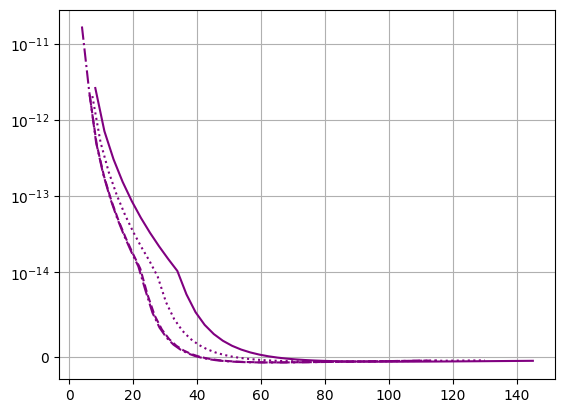

In [485]:
cols = {0.1: "red", 0.3: "orange", 0.5: "green", 0.7: "blue", 0.9: "purple"}
lnsty = {0.9: "solid", 0.5: "dotted", 0.1: "dashed", 1e-4: "dashdot"}
for a in [0.9]:#, 0.3, 0.5, 0.7, 0.9]:
    for e in [0.9, 0.5, 0.1, 1e-4]:
        key = (a, e)
        tilt = "Retrograde Near Polar"
        rs = big_dict[key]["Radial"][0]
        dL2 = 2 * big_dict[key]["Radial"][1][tilt][1][:, 1] * big_dict[key]["Radial"][1][tilt][1][:, 6]
        plt.plot(rs, dL2, c=cols[a], linestyle=lnsty[e])
        #print(f"{str(key): ^15}: Min = {np.nanmin(dL2):.7e}, Max = {np.nanmax(dL2):.7e}")
        #print(f"{"hey":@^10}")
plt.yscale("symlog", linthresh=1e-14)
plt.grid()

121.0
60.5
18.15
8.5
6.785
4.825


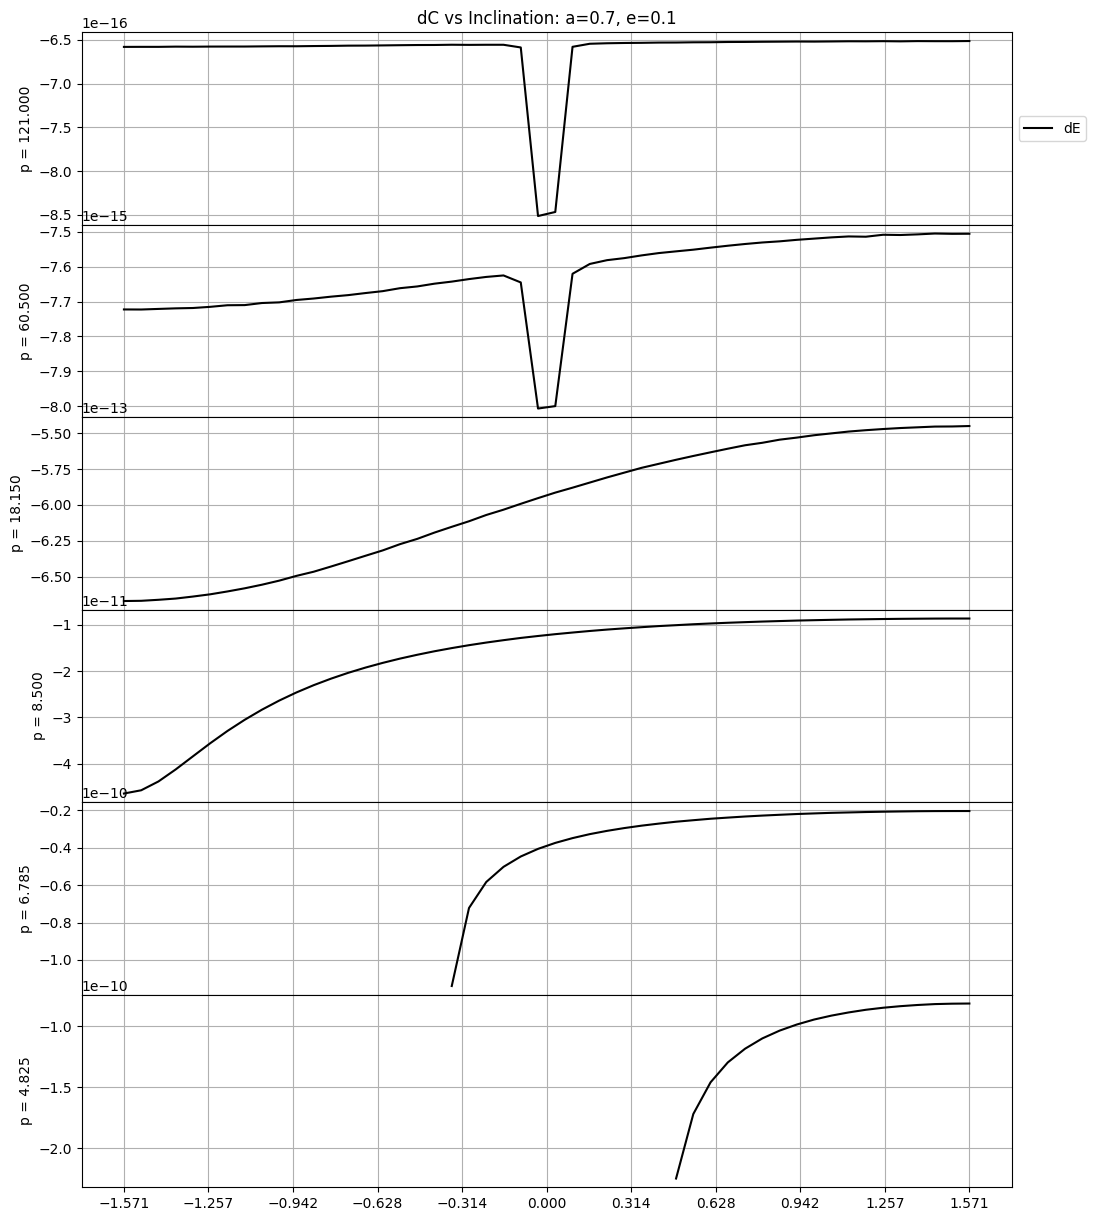

121.0
60.5
18.15
8.5
6.785
4.825


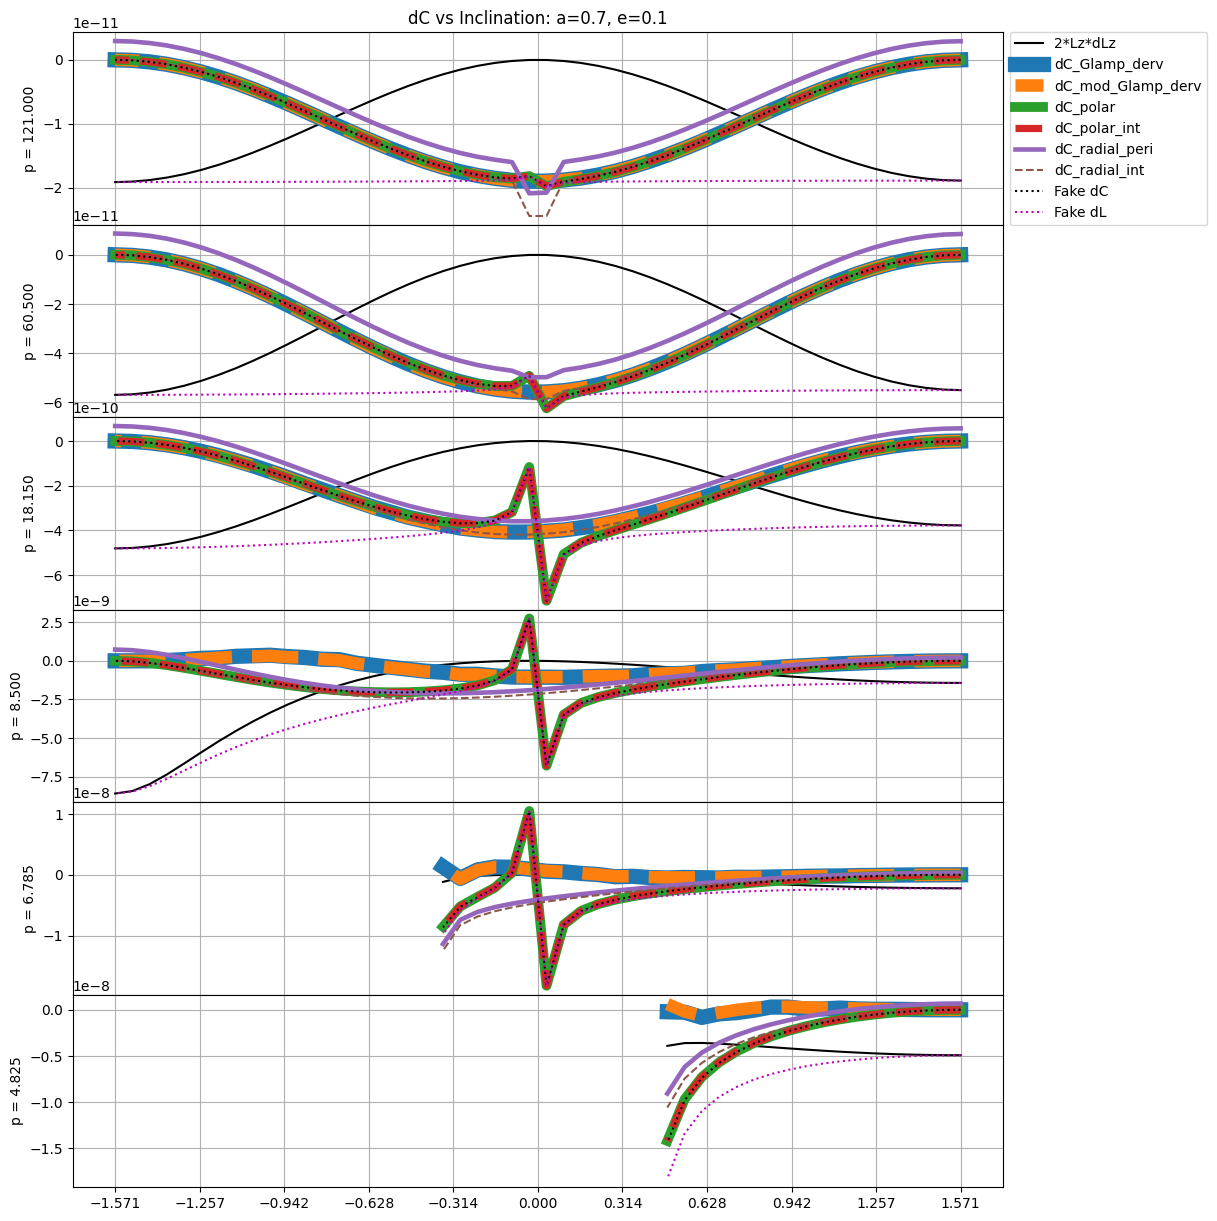

121.0
60.5
18.15
8.5
6.785
4.825


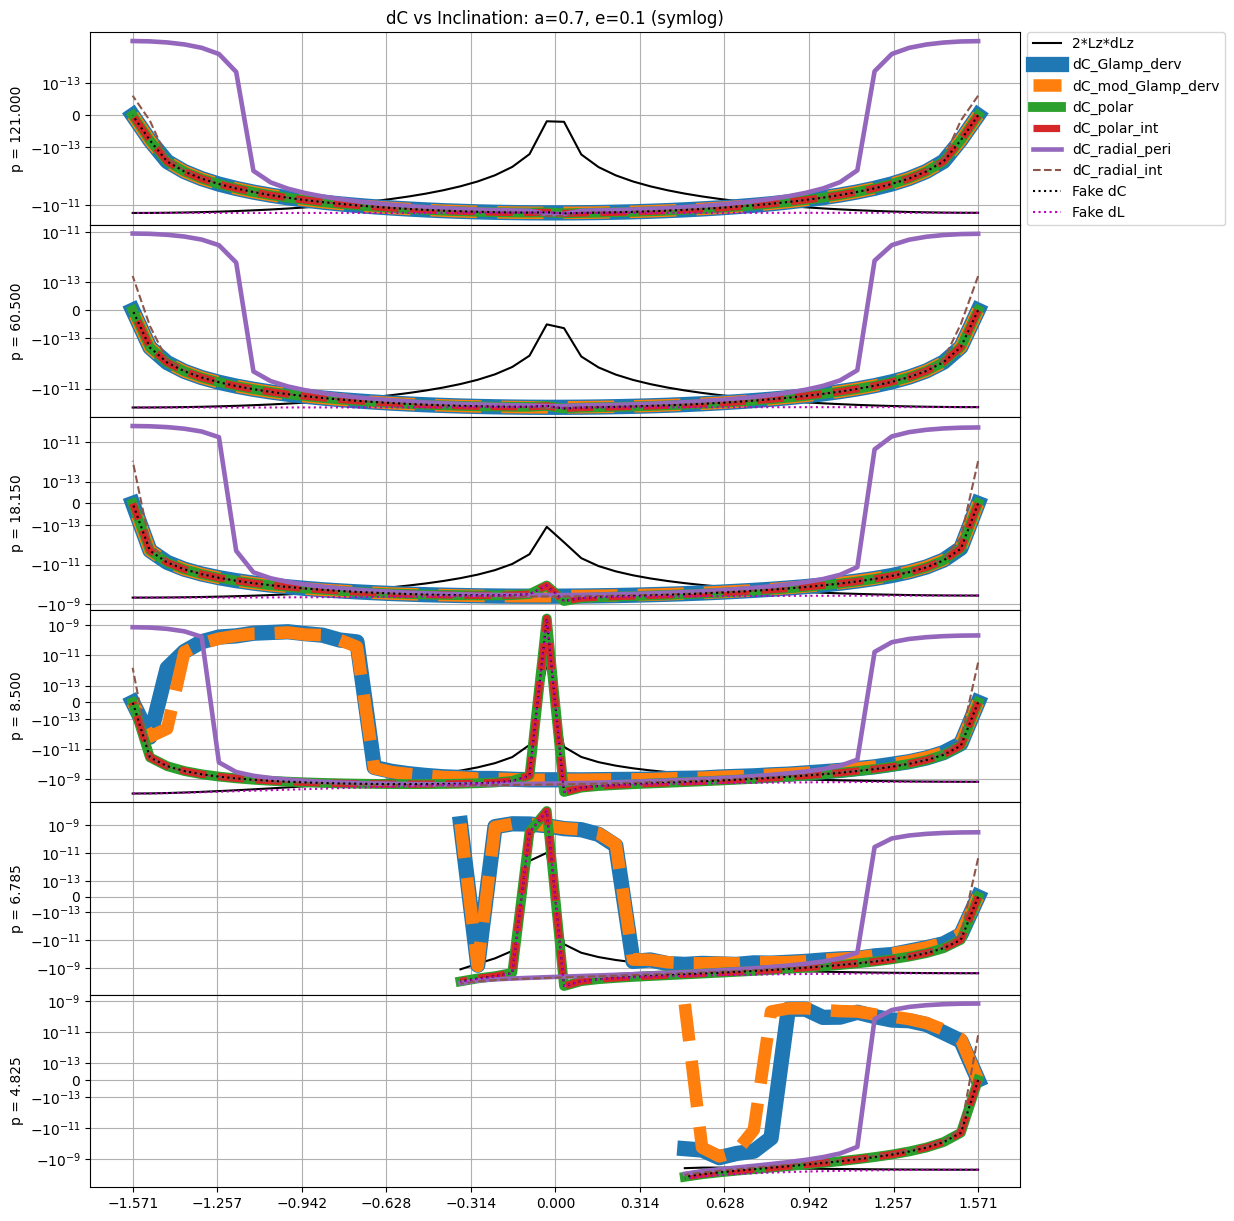

1.5707963267948966
0.7853981633974483
0.008726646259971648
-0.008726646259971648
-0.7853981633974483
-1.5707963267948966


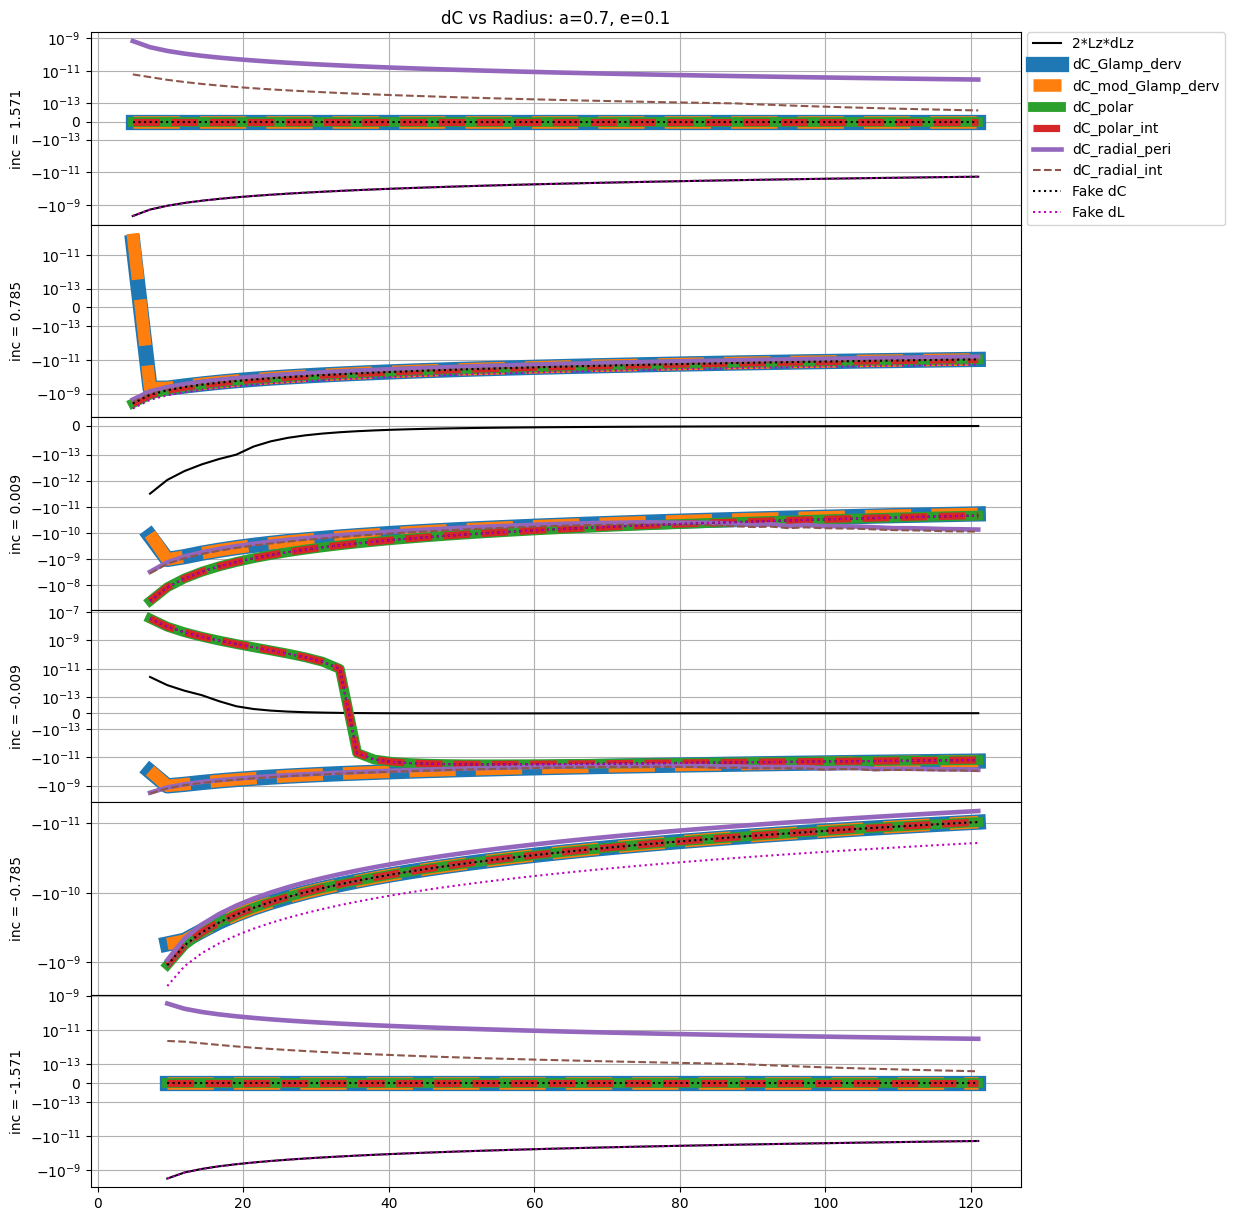

1.5707963267948966
0.7853981633974483
0.008726646259971648
-0.008726646259971648
-0.7853981633974483
-1.5707963267948966


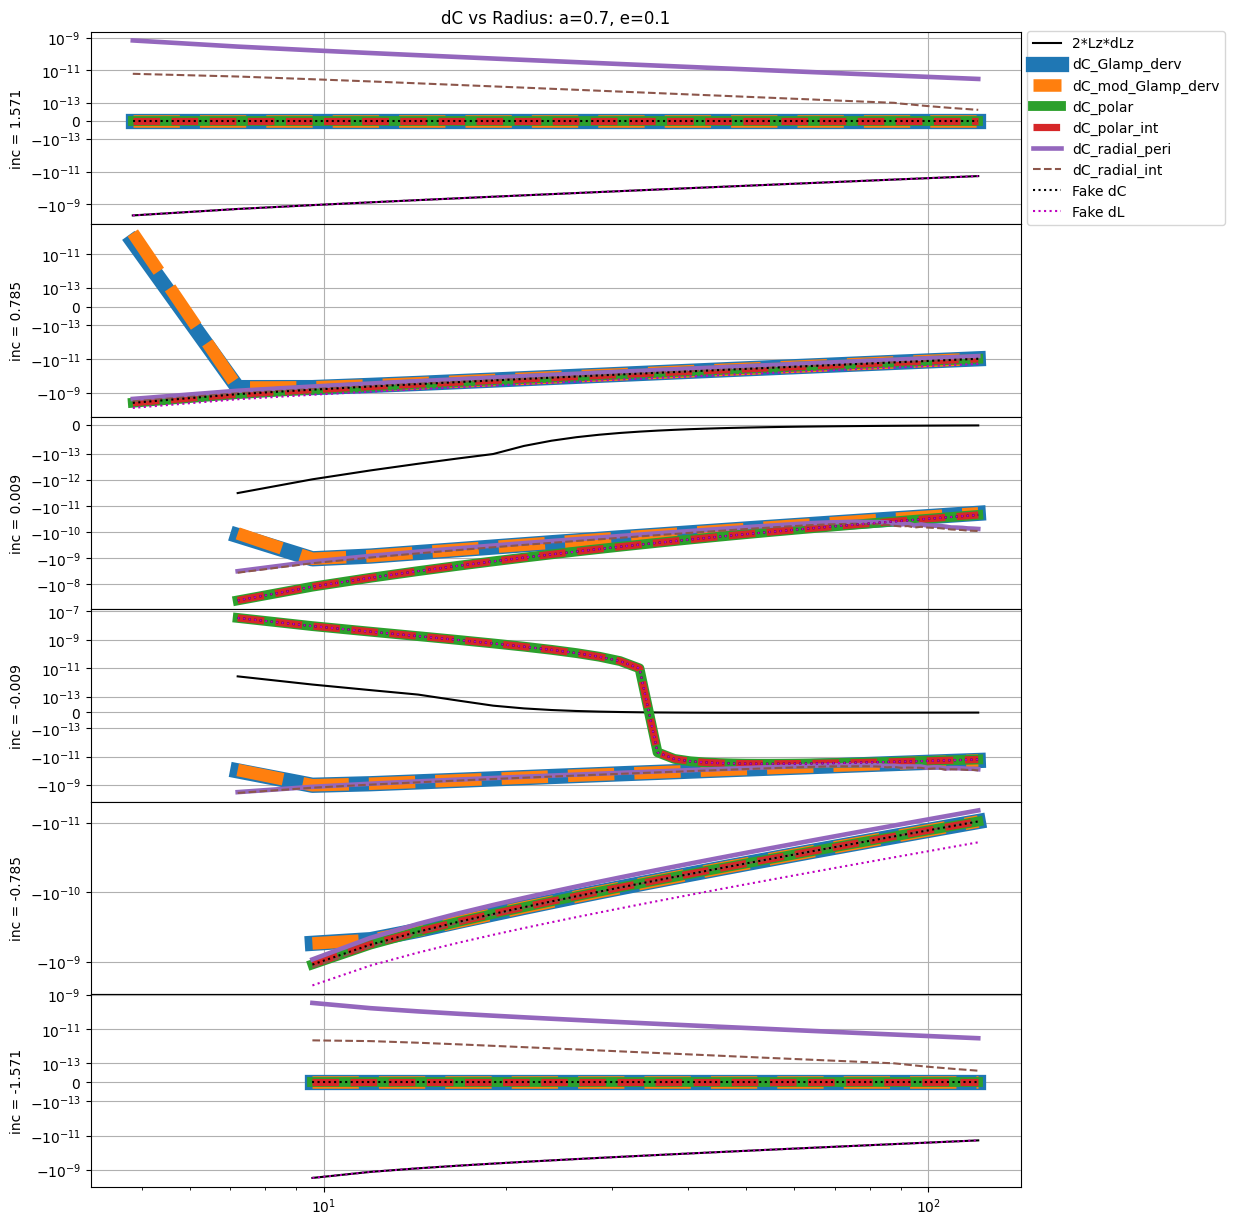

In [26]:
#print(big_dict[0.1, 0.1]["Angular"][1]["Very Weak Field"][1][:, 7])

a, e = 0.7, 0.1
ix_labs = ["E0", "L0", "C0",                 # initial constants (0-2)
           "dE", "dLx", "dLy", "dLz",          # changes calculated from Peters (1964)  (3 - 6)
           "dC_least_squares",           # 7
           "dC_mod_least_squares",       # 8
           "dC_Glamp_derv",              # 9
           "dC_mod_Glamp_derv",          # 10
           "dC_polar",                   # 11
           "dC_polar_diff",              # 12
           "dC_polar_int",               # 13
           "dC_radial_pot_min",          # 14
           "dC_radial_apo",              # 15
           "dC_radial_peri",             # 16
           "dC_radial_semilat",          # 17
           "dC_radial_int"]              # 18

fig, ax = plt.subplots(len(list(big_dict[a, e]["Angular"][1].keys())), 1, sharex=True, figsize=((12, 15)), gridspec_kw={"hspace":0})
i = 0
ax[0].set_title(f"dC vs Inclination: a={a}, e={e}")
for v in big_dict[a, e]["Angular"][1].keys():
    print(big_dict[a, e]["Angular"][1][v][0])
    ax[i].plot(big_dict[a, e]["Angular"][0], big_dict[a, e]["Angular"][1][v][1][:, 3], label="dE", c="k")
    ax[i].set_ylabel(f"p = {big_dict[a, e]["Angular"][1][v][0]:.3f}")
    ax[i].grid()
    if i == 0:
        ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    i += 1
plt.xticks(np.linspace(-np.pi/2, np.pi/2, 11))
plt.show()

ixs = [9, 10, 11, 13, 16, 18]
lw = len(ixs) * 2 - 1
fig, ax = plt.subplots(len(list(big_dict[a, e]["Angular"][1].keys())), 1, sharex=True, figsize=((12, 15)), gridspec_kw={"hspace":0})
i = 0
ax[0].set_title(f"dC vs Inclination: a={a}, e={e}")
for v in big_dict[a, e]["Angular"][1].keys():
    print(big_dict[a, e]["Angular"][1][v][0])
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6], label="2*Lz*dLz", c="k")
    for j in range(len(ixs)):
        if j%2 == 0:
            ax[i].plot(big_dict[a, e]["Angular"][0], big_dict[a, e]["Angular"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linewidth = lw - 2*j*(0.99**j))
        else:
            ax[i].plot(big_dict[a, e]["Angular"][0], big_dict[a, e]["Angular"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linestyle="--", linewidth= lw - 2*j*(0.99**j))
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6] * (np.cos(big_dict[a, e]["Angular"][0])/np.sin(big_dict[a, e]["Angular"][0]))**2, label="Fake dC", c="k", linestyle=":")
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6] * (1/np.sin(big_dict[a, e]["Angular"][0]))**2, label="Fake dL", c="m", linestyle=":")
    ax[i].set_ylabel(f"p = {big_dict[a, e]["Angular"][1][v][0]:.3f}")
    ax[i].grid()
    if i == 0:
        ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    i += 1
plt.xticks(np.linspace(-np.pi/2, np.pi/2, 11))
plt.show()

fig, ax = plt.subplots(len(list(big_dict[a, e]["Angular"][1].keys())), 1, sharex=True, figsize=((12, 15)), gridspec_kw={"hspace":0})
i = 0
ax[0].set_title(f"dC vs Inclination: a={a}, e={e} (symlog)")
for v in big_dict[a, e]["Angular"][1].keys():
    print(big_dict[a, e]["Angular"][1][v][0])
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6], label="2*Lz*dLz", c="k")
    for j in range(len(ixs)):
        if j%2 == 0:
            ax[i].plot(big_dict[a, e]["Angular"][0], big_dict[a, e]["Angular"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linewidth= lw - 2*j*(0.99**j))
        else:
            ax[i].plot(big_dict[a, e]["Angular"][0], big_dict[a, e]["Angular"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linestyle="--", linewidth= lw - 2*j*(0.99**j))
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6] * (np.cos(big_dict[a, e]["Angular"][0])/np.sin(big_dict[a, e]["Angular"][0]))**2, label="Fake dC", c="k", linestyle=":")
    ax[i].plot(big_dict[a, e]["Angular"][0], 2 * big_dict[a, e]["Angular"][1][v][1][:, 1] * big_dict[a, e]["Angular"][1][v][1][:, 6] * (1/np.sin(big_dict[a, e]["Angular"][0]))**2, label="Fake dL", c="m", linestyle=":")
    #ax[i].set_xlim(-1.05*np.pi/2, 1.05*np.pi/2)
    ax[i].set_yscale("symlog", linthresh=1e-13)
    ax[i].set_ylabel(f"p = {big_dict[a, e]["Angular"][1][v][0]:.3f}")
    ax[i].grid()
    if i == 0:
        ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    i += 1
plt.xticks(np.linspace(-np.pi/2, np.pi/2, 11))
plt.show()

fig, ax = plt.subplots(len(list(big_dict[a, e]["Radial"][1].keys())), 1, sharex=True, figsize=((12, 15)), gridspec_kw={"hspace":0})
i = 0
ax[0].set_title(f"dC vs Radius: a={a}, e={e}")
for v in big_dict[a, e]["Radial"][1].keys():
    print(big_dict[a, e]["Radial"][1][v][0])
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6], label="2*Lz*dLz", c="k")
    for j in range(len(ixs)):
        if j%2 == 0:
            ax[i].plot(big_dict[a, e]["Radial"][0], big_dict[a, e]["Radial"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linewidth= lw - 2*j*(0.99**j))
        else:
            ax[i].plot(big_dict[a, e]["Radial"][0], big_dict[a, e]["Radial"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linestyle="--", linewidth= lw - 2*j*(0.99**j))
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6] * (np.cos(big_dict[a, e]["Radial"][1][v][0])/np.sin(big_dict[a, e]["Radial"][1][v][0]))**2, label="Fake dC", c="k", linestyle=":")
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6] * (1/np.sin(big_dict[a, e]["Radial"][1][v][0]))**2, label="Fake dL", c="m", linestyle=":")
    ax[i].set_ylabel(f"inc = {big_dict[a, e]["Radial"][1][v][0]:.3f}")
    ax[i].set_yscale("symlog", linthresh=1e-13)
    ax[i].grid()
    if i == 0:
        ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    i += 1
plt.show()

fig, ax = plt.subplots(len(list(big_dict[a, e]["Radial"][1].keys())), 1, sharex=True, figsize=((12, 15)), gridspec_kw={"hspace":0})
i = 0
ax[0].set_title(f"dC vs Radius: a={a}, e={e}")
for v in big_dict[a, e]["Radial"][1].keys():
    print(big_dict[a, e]["Radial"][1][v][0])
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6], label="2*Lz*dLz", c="k")
    for j in range(len(ixs)):
        if j%2 == 0:
            ax[i].plot(big_dict[a, e]["Radial"][0], big_dict[a, e]["Radial"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linewidth= lw - 2*j*(0.99**j))
        else:
            ax[i].plot(big_dict[a, e]["Radial"][0], big_dict[a, e]["Radial"][1][v][1][:, ixs[j]], label=ix_labs[ixs[j]], linestyle="--", linewidth= lw - 2*j*(0.99**j))
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6] * (np.cos(big_dict[a, e]["Radial"][1][v][0])/np.sin(big_dict[a, e]["Radial"][1][v][0]))**2, label="Fake dC", c="k", linestyle=":")
    ax[i].plot(big_dict[a, e]["Radial"][0], 2 * big_dict[a, e]["Radial"][1][v][1][:, 1] * big_dict[a, e]["Radial"][1][v][1][:, 6] * (1/np.sin(big_dict[a, e]["Radial"][1][v][0]))**2, label="Fake dL", c="m", linestyle=":")
    ax[i].set_ylabel(f"inc = {big_dict[a, e]["Radial"][1][v][0]:.3f}")
    ax[i].set_yscale("symlog", linthresh=1e-13)
    ax[i].set_xscale("log")
    ax[i].grid()
    if i == 0:
        ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    i += 1
plt.show()

[  4.875        5.20075167   5.54827035   5.91901052   6.31452387
   6.73646576   7.18660217   7.66681707   8.17912035   8.72565617
   9.30871199   9.93072809  10.59430784  11.30222855  12.05745314
  12.86314247  13.72266866  14.63962913  15.61786167  16.66146056
  17.77479361  18.96252053  20.22961238  21.58137239  23.02345816
  24.56190534  26.20315288  27.95406997  29.82198485  31.8147154
  33.94060191  36.20854198  38.62802774  41.20918561  43.96281866
  46.90045183  50.03438015  53.37772025  56.9444652   60.7495431
  64.80887956  69.13946435  73.75942253  78.68809026  83.9460958
  89.55544576  95.53961728 101.92365627 108.73428221 116.        ]
[  4.875        4.875        4.875        4.875        4.875
   4.875        4.875        4.875        4.875        4.875
   4.875        4.875        4.875        4.875        4.875
   4.87500001   4.87500001   4.87500003   4.87500005   4.8750001
   4.87500021   4.87500041   4.87500083   4.87500166   4.87500331
   4.87500662   4.87501325  

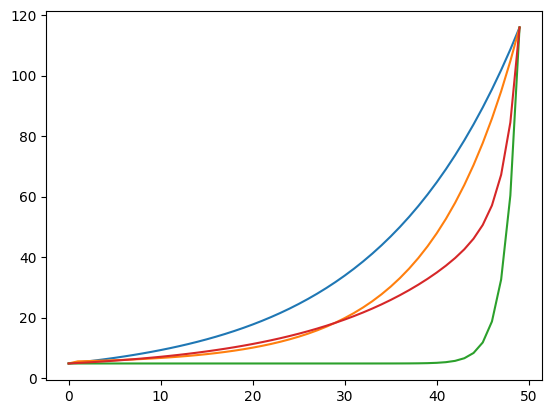

In [48]:
big, small = 116, 4.875
plt.plot(np.geomspace(small, big))

lst = []
while len(lst) < 49:
    lst.append(big)
    big = big - (1/10)*(big - small)
lst.append(small)
plt.plot(lst[::-1])

big, small = 116, 4.875
lst = []
while len(lst) < 49:
    lst.append(big)
    big = 0.5*(big + small)
lst.append(small)

plt.plot(lst[::-1])

big, small = 116, 4.875
plt.plot(0.5*(np.geomspace(small, big) + np.array(lst[::-1])))

print(np.geomspace(small, big))
print(np.array(lst[::-1]))
print(0.5*(np.geomspace(small, big) + np.array(lst[::-1])))

[74.94597647 66.13307647 58.3590417  51.50157547 45.4527885  40.11750224
 35.41175198 31.26146636 27.60130233 24.37361734 21.52756252 19.01828271
 16.80621062 14.85644408 13.13819656 11.62431235 10.29083864  9.11664795
  8.08310477  7.17377124  6.37414722  5.67144067  5.0543646   4.51295761
  4.03842506  3.62299849  3.2598112   2.94278811  2.66654849  2.42632017
  2.21786425  2.03740936  1.88159483  1.74742194  1.6322125   1.5335741
  1.44937095  1.37769932  1.31686676  1.26537385  1.22189782  1.18527737
  1.15449822  1.12867915  1.10705861  1.08898171  1.07388801  1.06129992
  1.05081206  1.04208157]
[74.79203586 65.96918207 58.18454988 51.315801   45.25500184 39.90692663
 35.18756046 31.02277847 27.34718063 24.10306372 21.23951425 18.71160822
 16.47970496 14.50882407 12.76809554 11.23027452  9.87131289  8.669981
  7.60753357  6.66741425  5.83499431  5.09734086  4.44301101  3.86186787
  3.34491505  2.88414567  2.47240127  2.10323442  1.77076515  1.46951261
  1.19416222  0.93916814  0.

C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_3608\4133849653.py:6: RuntimeWarning: invalid value encountered in power
  plt.plot((1/(2*np.pi*(0.5*f)*G*M/(c**3)) - (a_0))**(2/3))
C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_3608\4133849653.py:7: RuntimeWarning: invalid value encountered in power
  print((1/(2*np.pi*(0.5*f)*G*M/(c**3)) - (a_0))**(2/3))
C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_3608\4133849653.py:14: RuntimeWarning: invalid value encountered in power
  plt.plot((1/(2*np.pi*(0.5*f)*G*M/(c**3)) - (a_0))**(2/3))


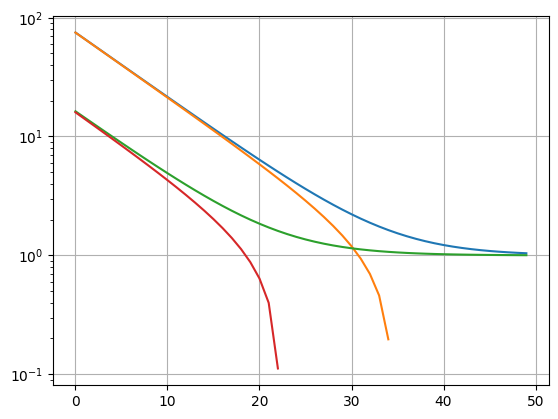

In [74]:
G, c, M, f = 6.67e-11, 3e8, 1.989e36, np.geomspace(0.0001, 1)
a_0 = -0.999
plt.plot((1/(2*np.pi*(0.5*f)*G*M/(c**3)) - (a_0))**(2/3))
print((1/(2*np.pi*(0.5*f)*G*M/(c**3)) - (a_0))**(2/3))
a_0 = 0.999
plt.plot((1/(2*np.pi*(0.5*f)*G*M/(c**3)) - (a_0))**(2/3))
print((1/(2*np.pi*(0.5*f)*G*M/(c**3)) - (a_0))**(2/3))

M = 1.989e37
a_0 = -0.999
plt.plot((1/(2*np.pi*(0.5*f)*G*M/(c**3)) - (a_0))**(2/3))
print((1/(2*np.pi*(0.5*f)*G*M/(c**3)) - (a_0))**(2/3))
a_0 = 0.999
plt.plot((1/(2*np.pi*(0.5*f)*G*M/(c**3)) - (a_0))**(2/3))

plt.yscale("log")
plt.grid()


In [83]:
test = [[0] * 10] * 5
print(test)
test[0][0] = 3
print(test)

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
[[3, 0, 0, 0, 0, 0, 0, 0, 0, 0], [3, 0, 0, 0, 0, 0, 0, 0, 0, 0], [3, 0, 0, 0, 0, 0, 0, 0, 0, 0], [3, 0, 0, 0, 0, 0, 0, 0, 0, 0], [3, 0, 0, 0, 0, 0, 0, 0, 0, 0]]


In [84]:
np.linspace(0, 1, 1)

array([0.])

In [85]:
np.shape("hello")

()

In [2]:
import pickle
with open("D:/EMRIData/final_big_dict.pkl", "rb") as f:
    test = pickle.load(f)

-3.5043697752251194e-15


C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_25780\2535252633.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="Blues_r")


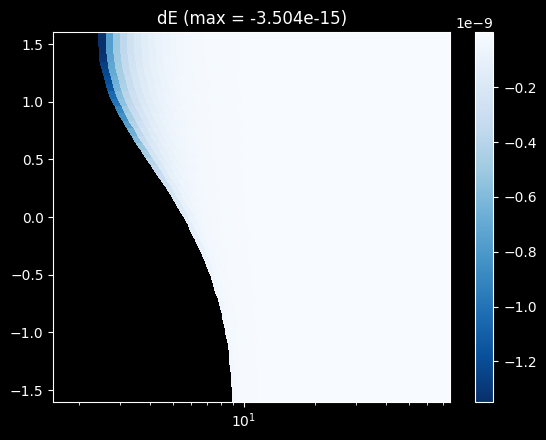

7.265146480721033e-11


C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_25780\2535252633.py:29: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="bwr", norm=norm)


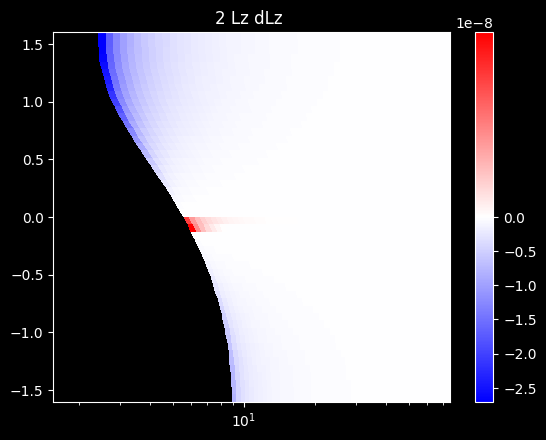

C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_25780\2535252633.py:47: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  global_plot = ax[0].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, test[a, e][1][:,:, i], vmin=-1e-8, vmax=1e-8, cmap="bwr")
C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_25780\2535252633.py:56: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  local_plot = ax[1].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="bwr", norm=norm)
C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_25780\2535252633.py:73: U

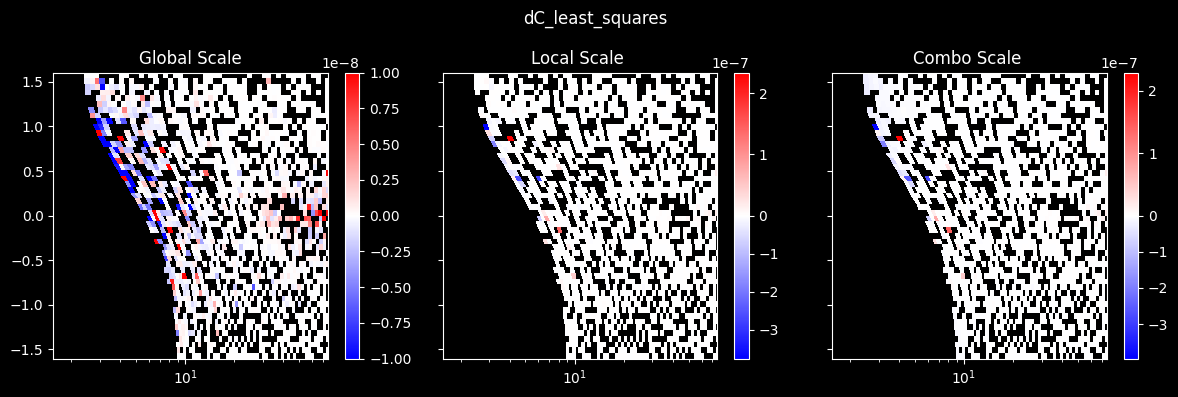

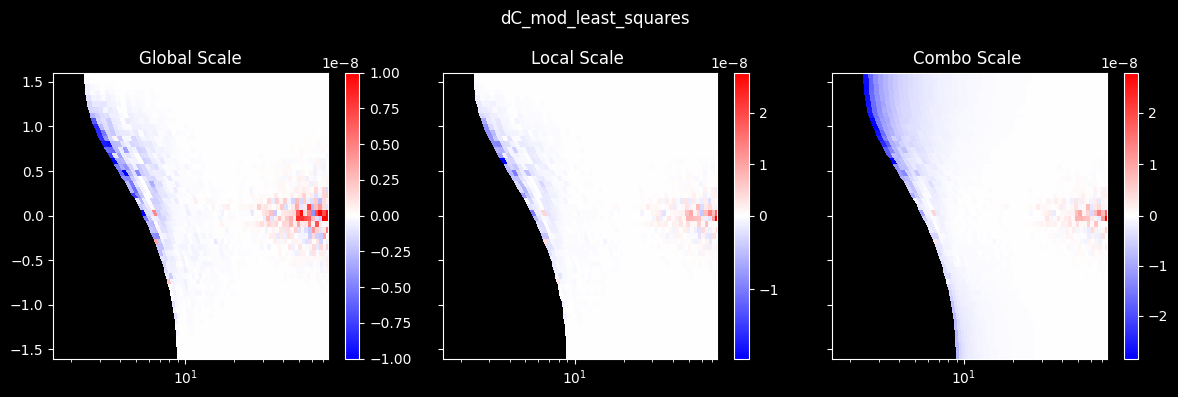

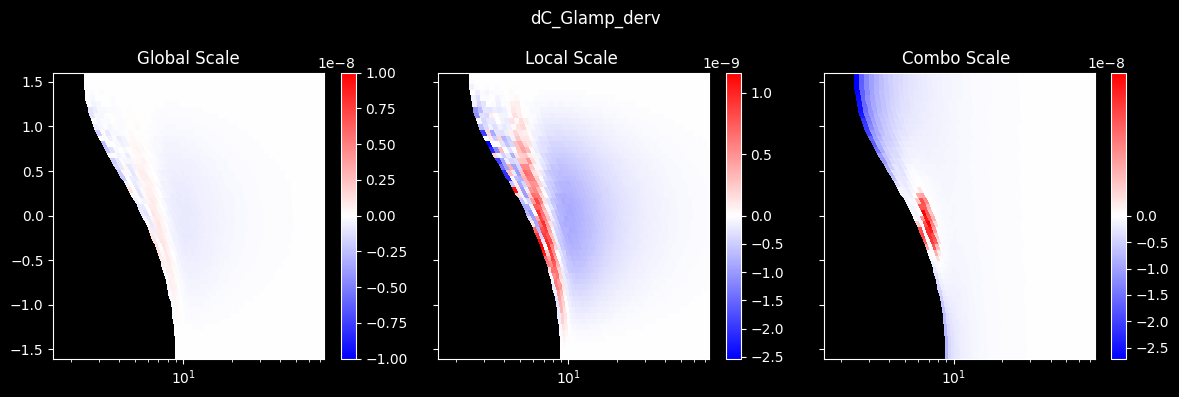

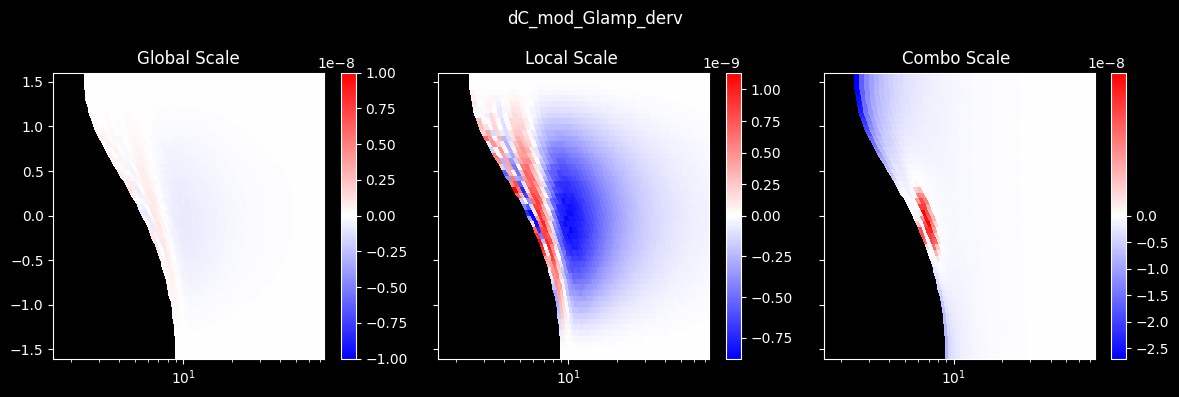

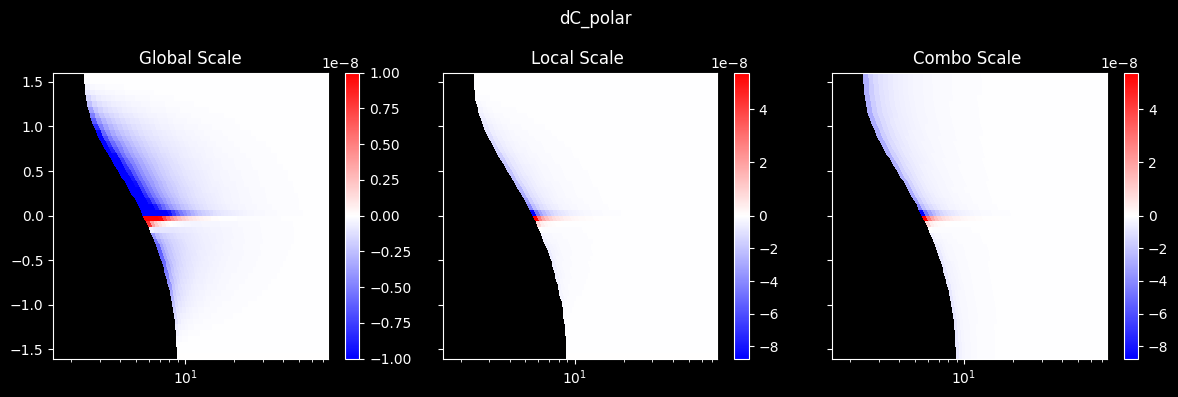

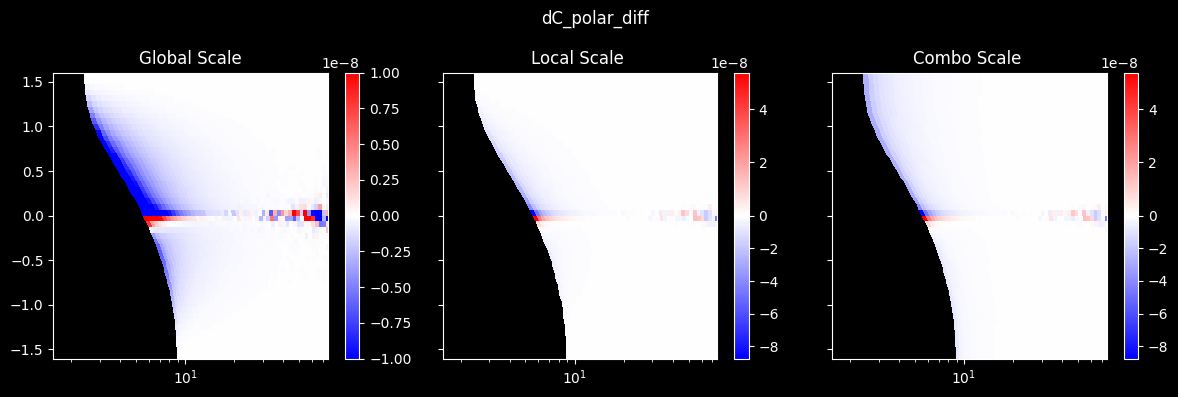

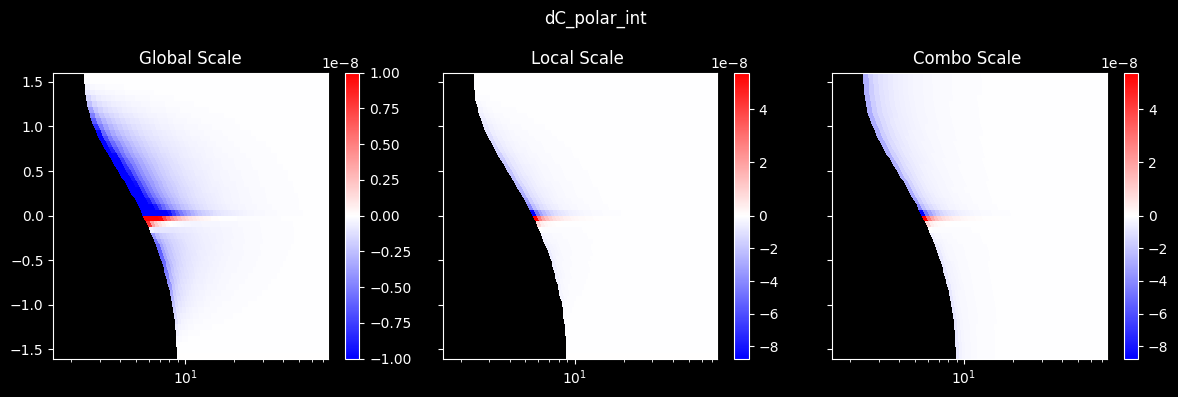

C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_25780\2535252633.py:63: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  local_plot = ax[1].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="Reds")
C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_25780\2535252633.py:79: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  combo_plot = ax[2].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="Reds")


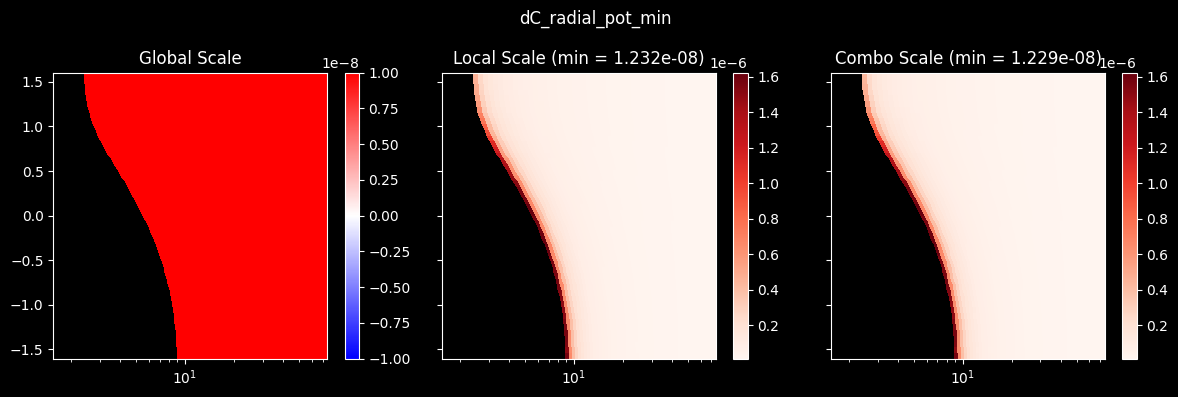

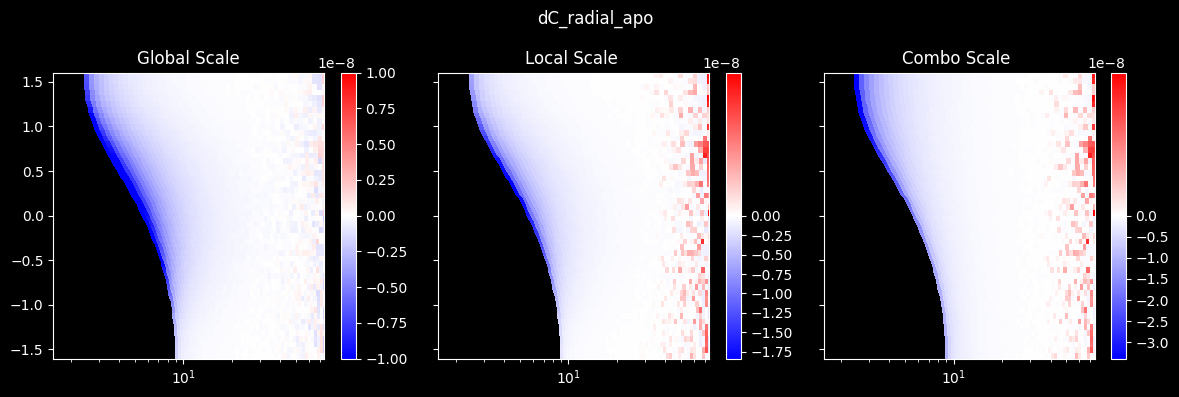

C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_25780\2535252633.py:76: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  combo_plot = ax[2].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="Blues_r")


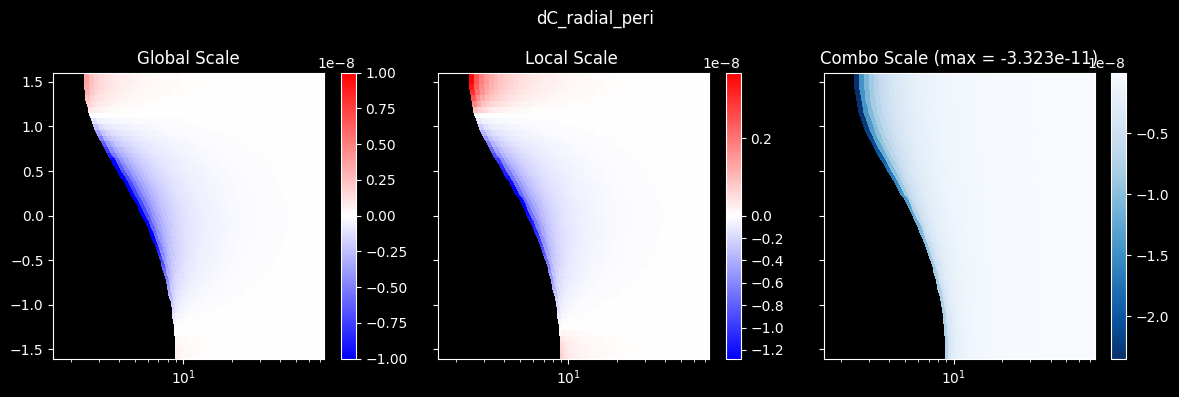

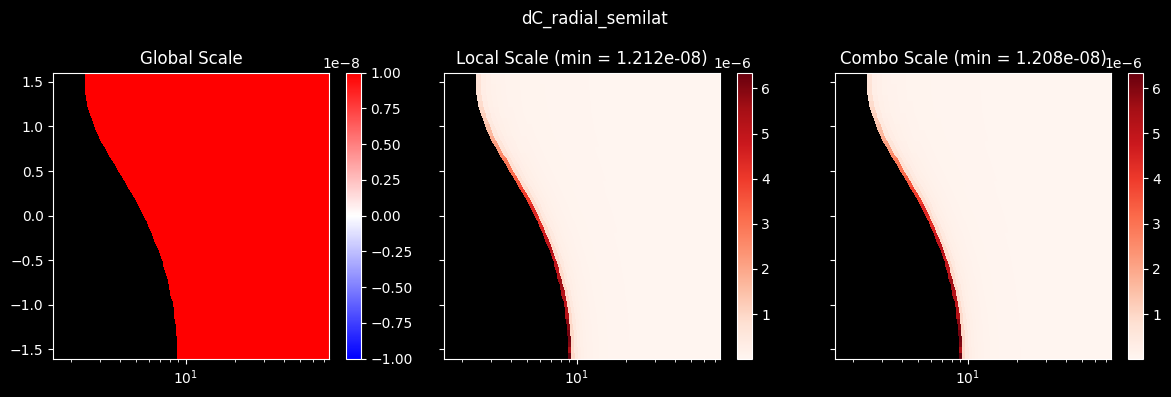

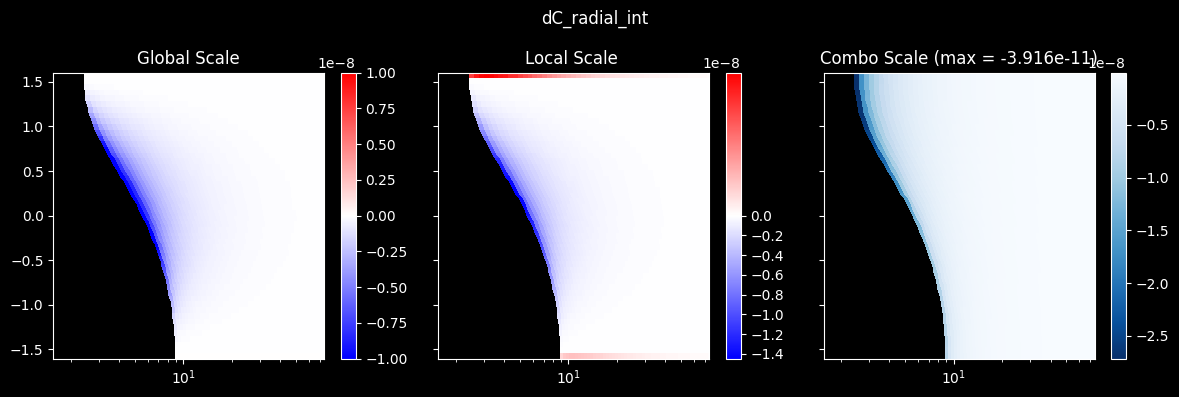

In [150]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import MetricMathStreamline as mm
plt.style.use('dark_background')
a, e = 0.9, 0.1
ix_labs = ["E0", "L0", "C0",                 # initial constants (0-2)
           "dE", "dLx", "dLy", "dLz",          # changes calculated from Peters (1964)  (3 - 6)
           "dC_least_squares",           # 7
           "dC_mod_least_squares",       # 8
           "dC_Glamp_derv",              # 9
           "dC_mod_Glamp_derv",          # 10
           "dC_polar",                   # 11
           "dC_polar_diff",              # 12
           "dC_polar_int",               # 13
           "dC_radial_pot_min",          # 14
           "dC_radial_apo",              # 15
           "dC_radial_peri",             # 16
           "dC_radial_semilat",          # 17
           "dC_radial_int"]              # 18


datas = [test[a, e][1][:, :, 3], 2*test[a, e][1][:,:, 1]*test[a, e][1][:,:, 6]]
smalls = ["dE", "2 Lz dLz"]
for i in range(2):
    data = datas[i]
    print(np.nanmax(data))
    try:
        norm = TwoSlopeNorm(vmin=np.nanmin(data), vcenter=0, vmax=np.nanmax(data))
        plt.pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="bwr", norm=norm)
        title_add = ""
    except:
        if np.nanmean(data) < 0.0:
            plt.pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="Blues_r")
            title_add = f"(max = {np.nanmax(data):.3e})"
        else:
            plt.pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="Reds")
            title_add = f"(min = {np.nanmin(data):.3e})"
    plt.colorbar()
    plt.xlim(mm.find_rph(a), np.nanmax(test[a, e][0]))
    plt.xscale("log")
    plt.title(smalls[i] + " " + title_add)
    plt.show()


for i in range(7, 19):
    fig, ax = plt.subplots(1, 3, sharey=True, figsize=(12, 4))
    global_plot = ax[0].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, test[a, e][1][:,:, i], vmin=-1e-8, vmax=1e-8, cmap="bwr")
    fig.colorbar(global_plot, ax=ax[0])
    ax[0].set_xlim(mm.find_rph(a), np.nanmax(test[a, e][0]))
    ax[0].set_xscale("log")
    ax[0].set_title("Global Scale")

    data = test[a, e][1][:,:, i]
    try:
        norm = TwoSlopeNorm(vmin=np.nanmin(data), vcenter=0, vmax=np.nanmax(data))
        local_plot = ax[1].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="bwr", norm=norm)
        title_add = ""
    except:
        if np.nanmean(data) < 0.0:
            local_plot = ax[1].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="Blues_r")
            title_add = f"(max = {np.nanmax(data):.3e})"
        else:
            local_plot = ax[1].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="Reds")
            title_add = f"(min = {np.nanmin(data):.3e})"
    fig.colorbar(local_plot, ax=ax[1])
    ax[1].set_xlim(mm.find_rph(a), np.nanmax(test[a, e][0]))
    ax[1].set_xscale("log")
    ax[1].set_title("Local Scale " + title_add)

    data = test[a, e][1][:,:, i] + 2*test[a, e][1][:,:, 1]*test[a, e][1][:,:, 6]
    try:
        norm = TwoSlopeNorm(vmin=np.nanmin(data), vcenter=0, vmax=np.nanmax(data))
        combo_plot = ax[2].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="bwr", norm=norm)
    except:
        if np.nanmean(data) < 0.0:
            combo_plot = ax[2].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="Blues_r") 
            title_add = f"(max = {np.nanmax(data):.3e})"
        else:
            combo_plot = ax[2].pcolormesh(test[a, e][0], np.tile(test["incs"], (len(test["incs"]), 1)).T, data, cmap="Reds") 
            title_add = f"(min = {np.nanmin(data):.3e})" 
    fig.colorbar(combo_plot, ax=ax[2])
    ax[2].set_xlim(mm.find_rph(a), np.nanmax(test[a, e][0]))
    ax[2].set_xscale("log")
    ax[2].set_title("Combo Scale " + title_add)

    #plt.xlim(7, 12)
    plt.suptitle(ix_labs[i])
    plt.tight_layout()
    plt.show()


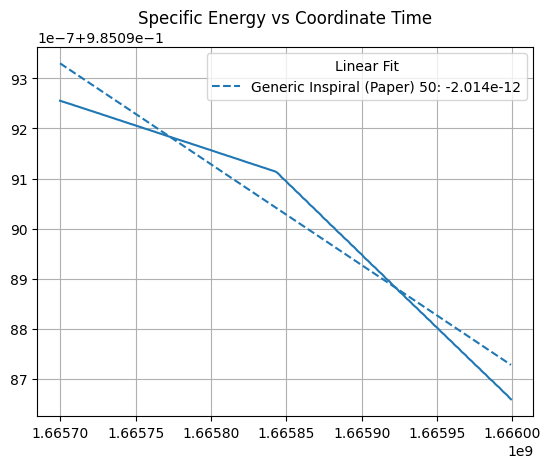

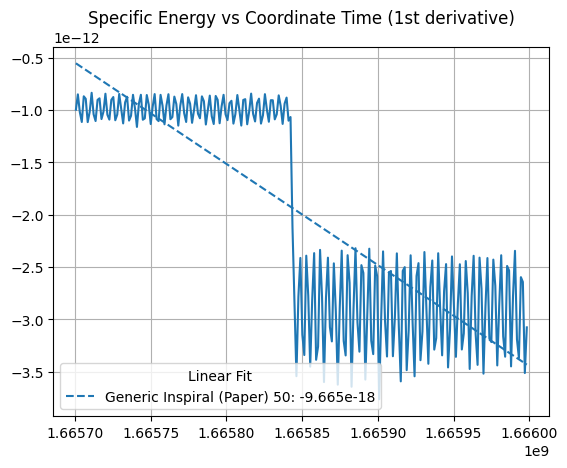

In [264]:
import MetricMathStreamline as mm
import MainLoopStreamline as ml
import OrbitPlotter as op
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import importlib
from tqdm import tqdm
importlib.reload(ml)
importlib.reload(mm)
importlib.reload(op)
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter

#gorf = ml.load_index()
#genera = [filename for filename, dat in gorf.items() if "Generic" in dat["Label"] and "differe" not in dat["Label"]]
#kink = ml.load_emri_data(genera[-30])
start, end = 1.6657e9, 1.666e9
'''op.plotvalue3(kink, "semilat", "ecc")
op.plotvalue3(kink, "tracktime", "energy", grid=True)
op.plotvalue3(kink, "tracktime", "energy", derv=1, grid=True)
op.plotvalue3(kink, "tracktime", "energy", start = start, end=end, grid=True)
if (kink["raw"][op.get_index(kink["time"], end), 3] - kink["raw"][op.get_index(kink["time"], start), 3])/(2 * np.pi) <= 30:
    op.plotvalue3(kink, "time", "radius", start = start, end=end, grid=True)
    op.plotvalue3(kink, "time", "phi", start = start, end=end, grid=True)
    op.plotvalue3(kink, "time", "phase", start = start, end=end, grid=True)
    op.plotvalue3(kink, "time", "theta", start = start, end=end, grid=True)
    

op.plotvalue3(kink, "tracktime", "energy", start = start, end=end, derv=1, grid=True)
if (kink["raw"][op.get_index(kink["time"], end), 3] - kink["raw"][op.get_index(kink["time"], start), 3])/(2 * np.pi) <= 30:
    op.plotvalue3(kink, "time", "radius", start = start, end=end, derv=1, grid=True)
    op.plotvalue3(kink, "time", "phi", start = start, end=end, derv=1, grid=True)
    op.plotvalue3(kink, "time", "phase", start = start, end=end, derv=1, grid=True)
    op.plotvalue3(kink, "time", "theta", start = start, end=end, derv=1, grid=True)
'''
op.plotvalue3(kink, "tracktime", "energy", start = start, end=end, grid=True)
op.plotvalue3(kink, "tracktime", "energy", start = start, end=end, derv=1, grid=True)
d_cons = []
ixs = kink["trackix"][op.get_index(kink["tracktime"], start): op.get_index(kink["tracktime"], end)]
quad_l = []
coolquad_l = []
dt2_l = []
dt3_l = []
int_time_l = []
int_time_cut_l = []
dedt_l = []
drv2_l = []
drv3_l = []
dedt_v2_l = []
dd2_l = []
dd3_l = []
dedt_v3_l = []
dldt_l = []
dldt_v2_l = []
dldt_v3_l = []
for i in range(len(ixs) - 1):
    states = kink["raw"][ixs[i]: ixs[i+1]]
    d_cons.append(mm.peters_integrate6_6_4(states, kink["spin"], 1e-3, ixs[i], ixs[i+1]))
    sphere, time = states[:, 1:4], states[:, 0]
    int_sphere, int_time = mm.interpolate(sphere, time, True)
    int_time_l.append(int_time)
    div = np.mean(np.diff(int_time))
    quad = mm.trace_ortholize_njit(int_sphere, a)
    quad_l.append(quad)
    delta = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
    coolquad = mm.traceless_quad(quad)
    coolquad_l.append(coolquad)
    dt = np.mean(np.diff(int_time))
    dt2, dt3 = mm.matrix_derive3_numba(coolquad, dt) 
    dt2 = dt2[5:-5]
    dt2_l.append(dt2)
    dt3 = dt3[5:-5]
    dt3_l.append(dt3)
    int_time = int_time[5:-5]
    int_time_cut_l.append(int_time)
    dedt = (-1/5)*(np.einsum('ijk,ijk ->i', dt3, dt3) - (1/3)*np.einsum('ijj,ikk ->i', dt3, dt3))
    dedt_l.append(dedt)
    dldt = mm.compute_dldt(dt2, dt3)
    dldt_l.append(dldt)
    # New tries
    drv1 = np.gradient(coolquad, dt, axis=0)
    drv2 = np.gradient(drv1, dt, axis=0)
    drv3 = np.gradient(drv2, dt, axis=0)
    drv2_l.append(drv2[5:-5])
    drv3_l.append(drv3[5:-5])
    dedt_v2 = (-1/5)*(np.einsum('ijk,ijk ->i', drv3[5:-5], drv3[5:-5]) - (1/3)*np.einsum('ijj,ikk ->i', drv3[5:-5], drv3[5:-5]))
    dedt_v2_l.append(dedt_v2)
    dldt_v2 = mm.compute_dldt(drv2[5:-5], drv3[5:-5])
    dldt_v2_l.append(dldt_v2)
    # Newer Tries
    dd1 = savgol_filter(coolquad, window_length=7, polyorder=3, deriv=1, delta=dt, axis=0)
    dd2 = savgol_filter(coolquad, window_length=7, polyorder=4, deriv=2, delta=dt, axis=0)
    dd3 = savgol_filter(coolquad, window_length=9, polyorder=5, deriv=3, delta=dt, axis=0)
    dd2_l.append(dd2[5:-5])
    dd3_l.append(dd3[5:-5])
    dedt_v3 = (-1/5)*(np.einsum('ijk,ijk ->i', dd3[5:-5], dd3[5:-5]) - (1/3)*np.einsum('ijj,ikk ->i', dd3[5:-5], dd3[5:-5]))
    dedt_v3_l.append(dedt_v3)
    dldt_v3 = mm.compute_dldt(dd2[5:-5], dd3[5:-5])
    dldt_v3_l.append(dldt_v3)

d_cons = np.array(d_cons)
quad_l = np.concatenate(quad_l)
coolquad_l = np.concatenate(coolquad_l)
dt2_l = np.concatenate(dt2_l)
dt3_l = np.concatenate(dt3_l)
int_time_l = np.concatenate(int_time_l)
int_time_cut_l = np.concatenate(int_time_cut_l)
dedt_l = np.concatenate(dedt_l)
drv2_l = np.concatenate(drv2_l)
drv3_l = np.concatenate(drv3_l)
dedt_v2_l = np.concatenate(dedt_v2_l)
dd2_l = np.concatenate(dd2_l)
dd3_l = np.concatenate(dd3_l)
dedt_v3_l = np.concatenate(dedt_v3_l)
dldt_l = np.concatenate(dldt_l)
dldt_v2_l = np.concatenate(dldt_v2_l)
dldt_v3_l = np.concatenate(dldt_v3_l)


(2300020, 3, 3)
(2300020,)
(2297720, 3, 3)
(2297720, 3, 3)
(2297720, 3, 3)
(2297720, 3, 3)
(2297720, 3, 3)
(2297720, 3, 3)
(2297720, 3)


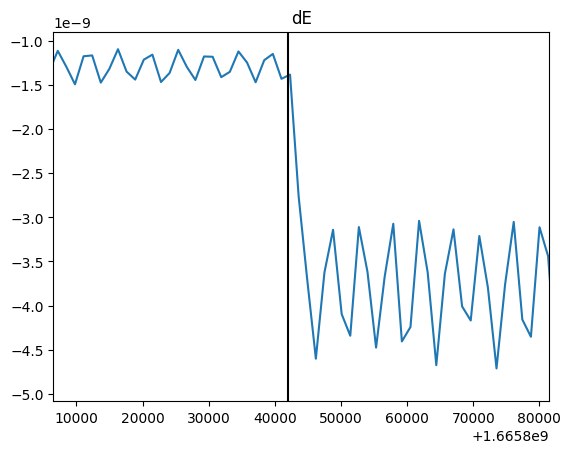

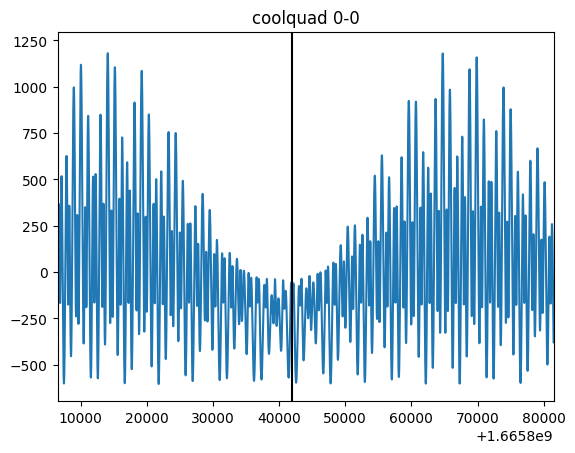

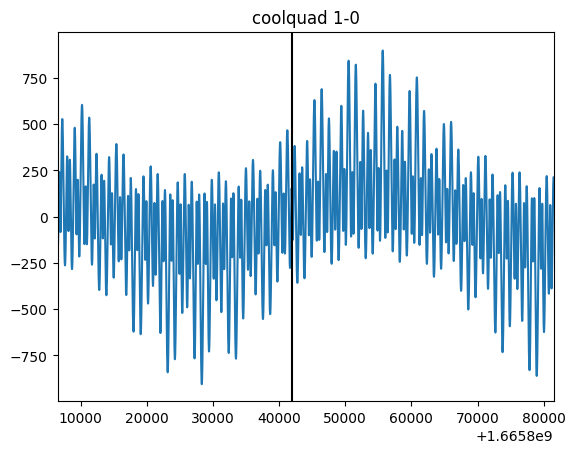

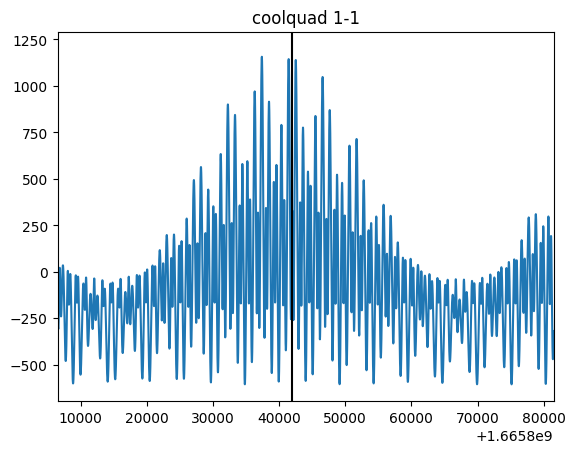

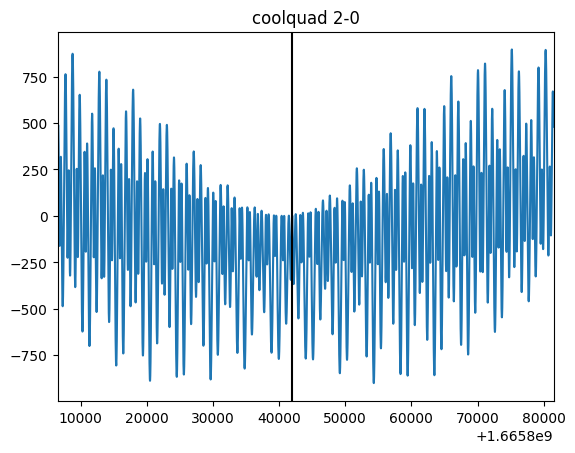

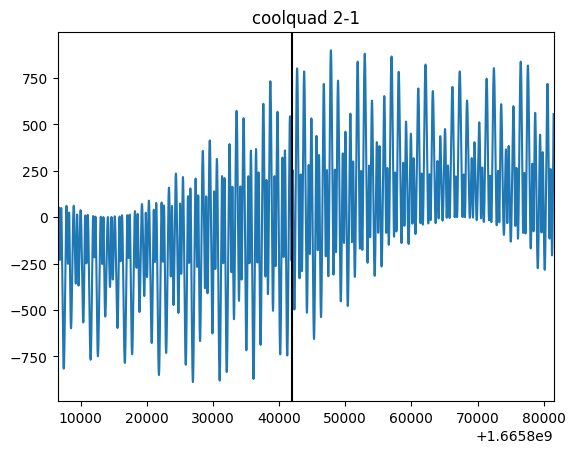

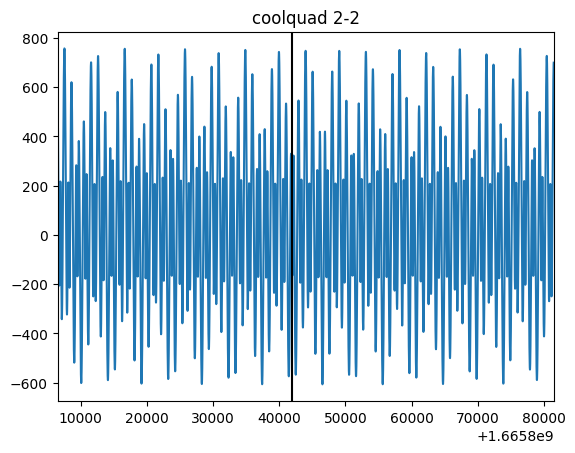

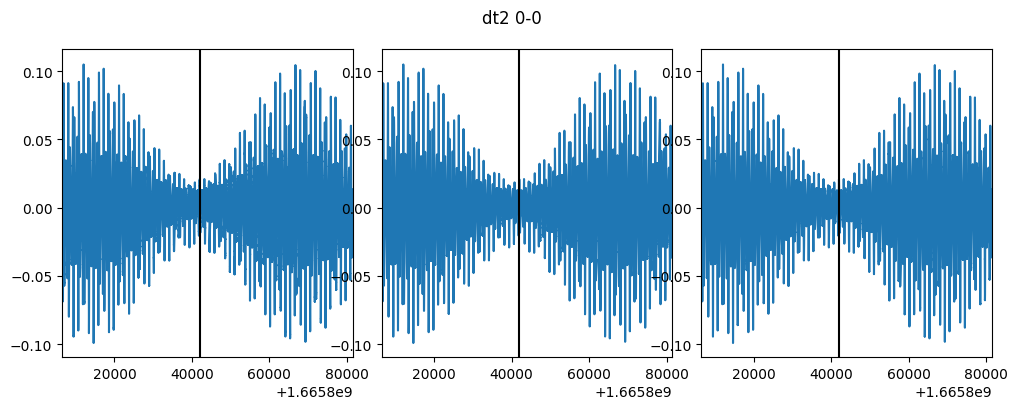

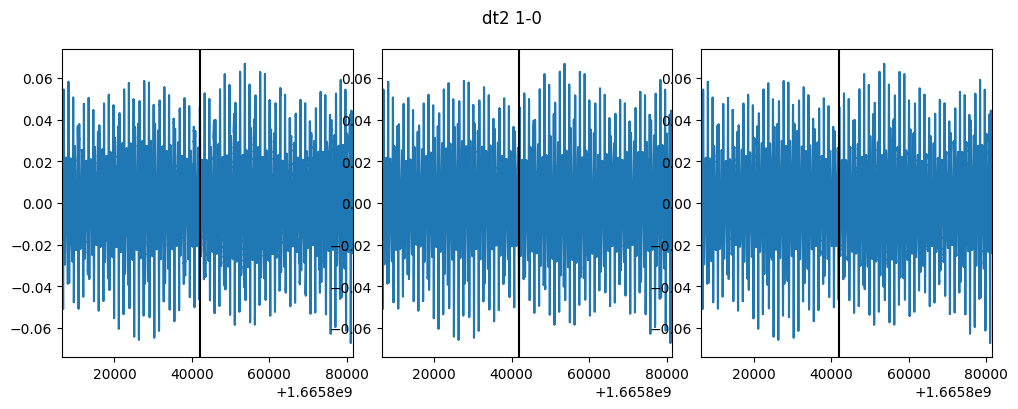

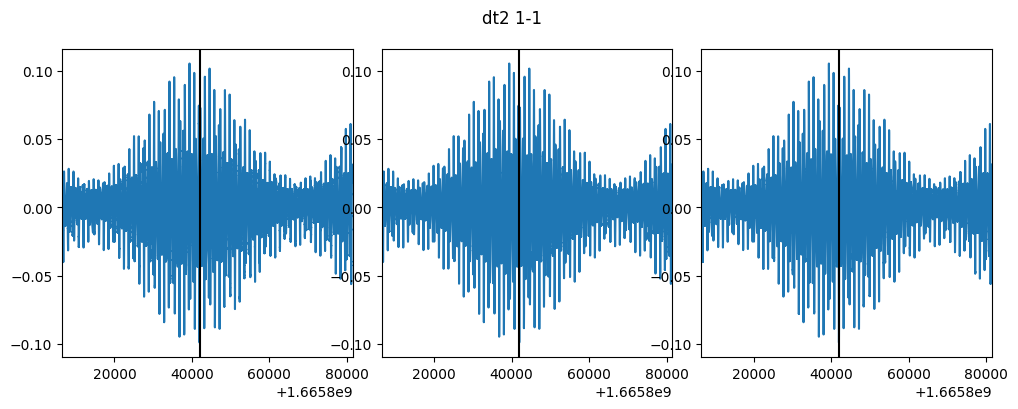

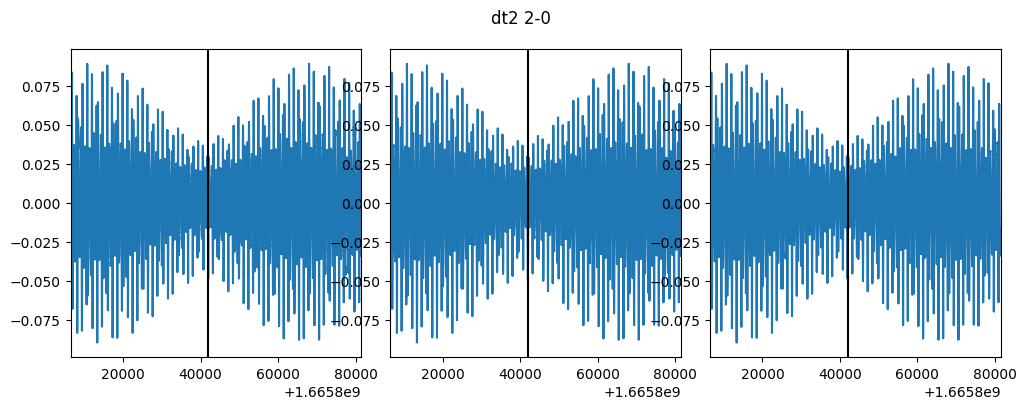

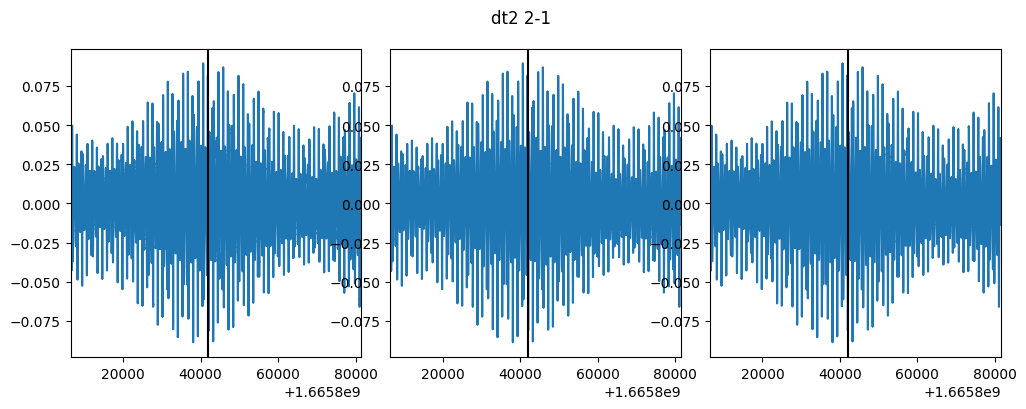

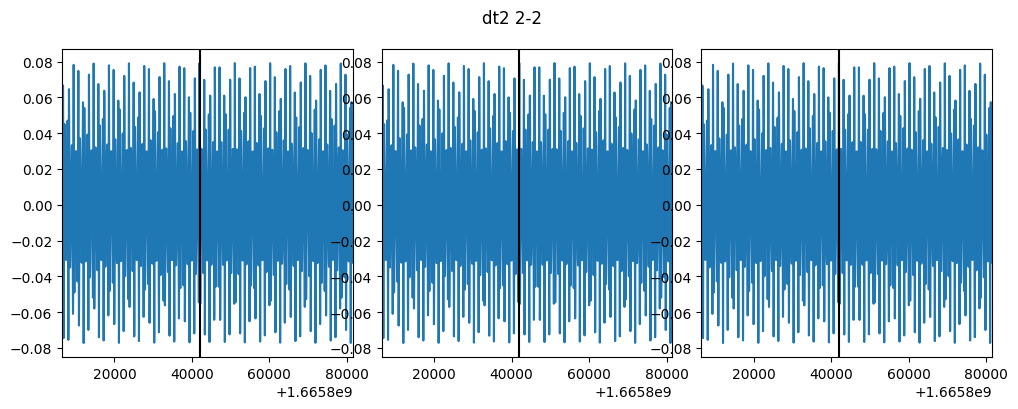

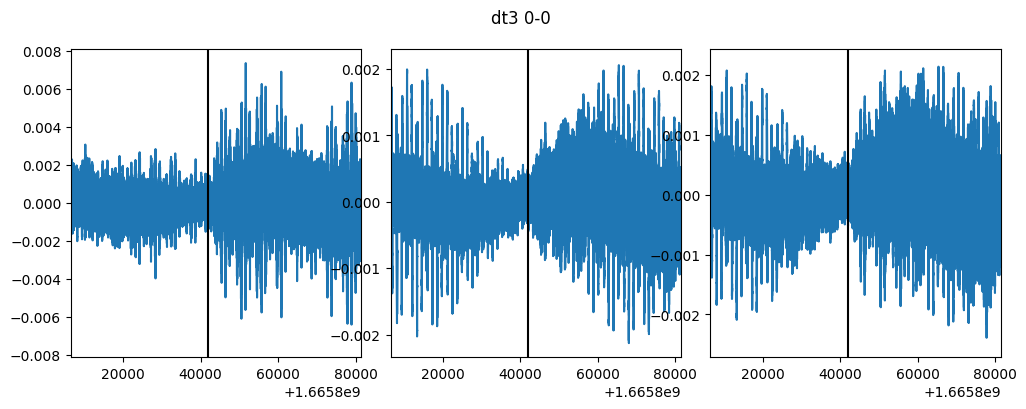

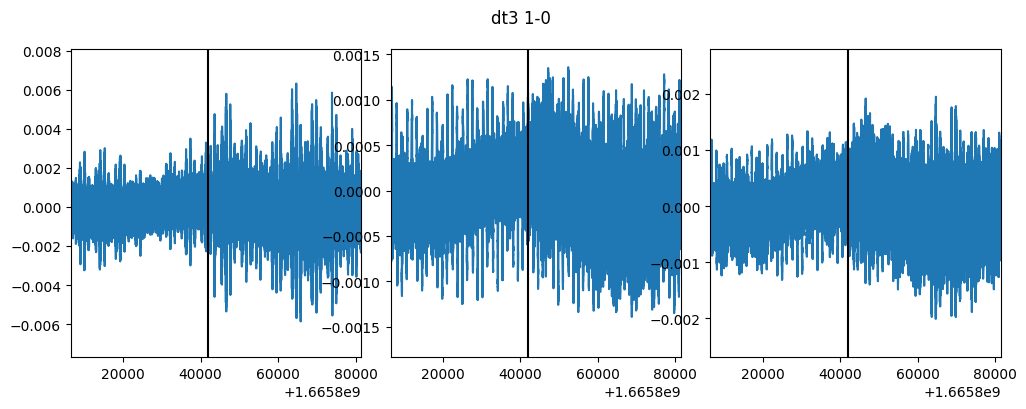

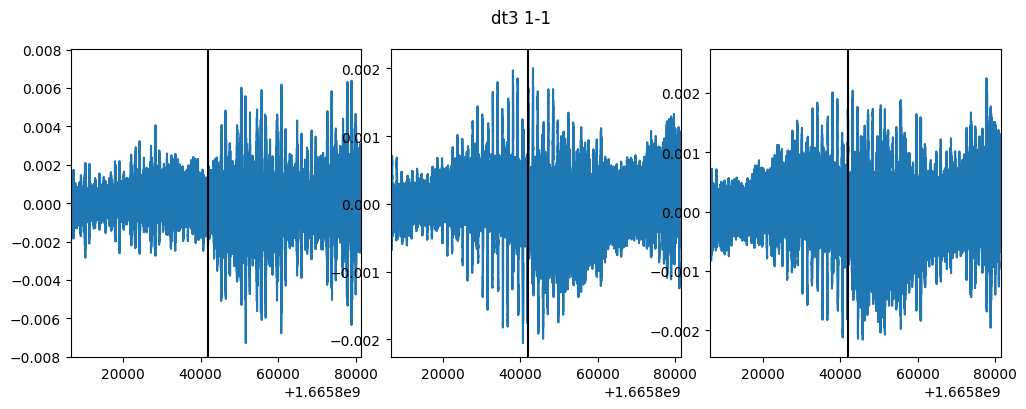

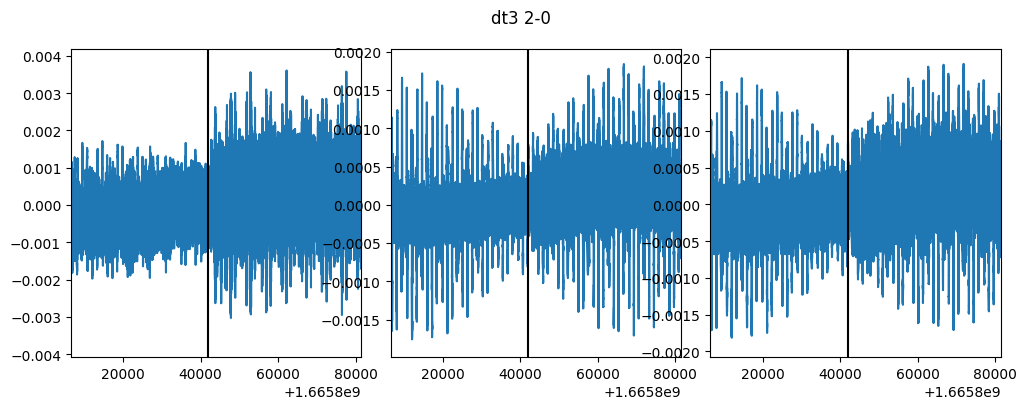

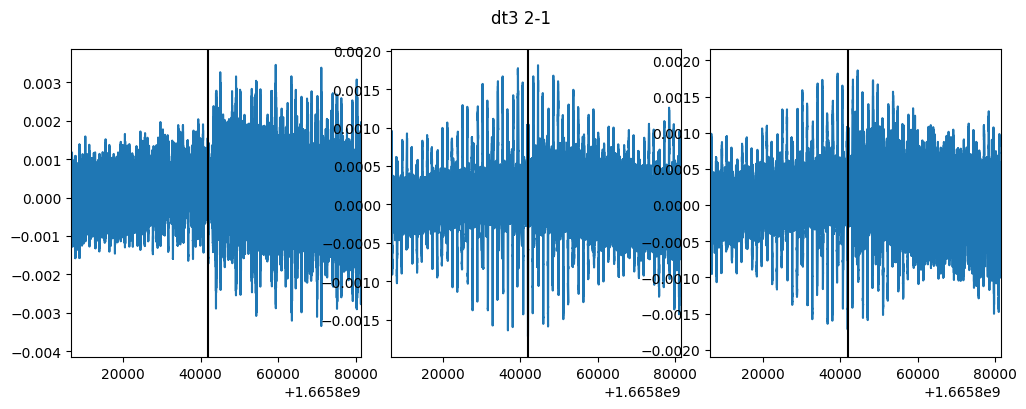

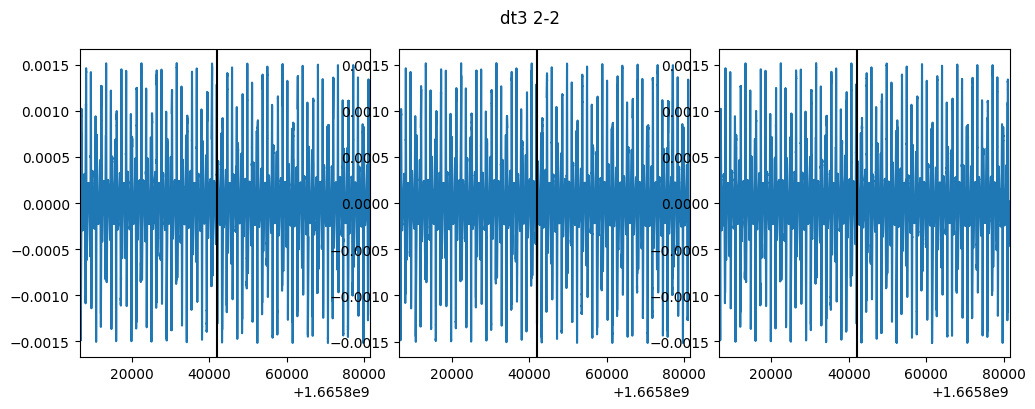

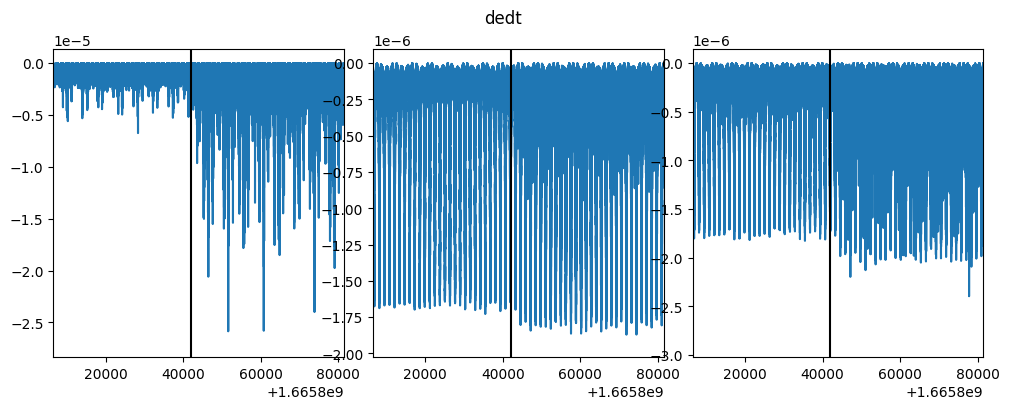

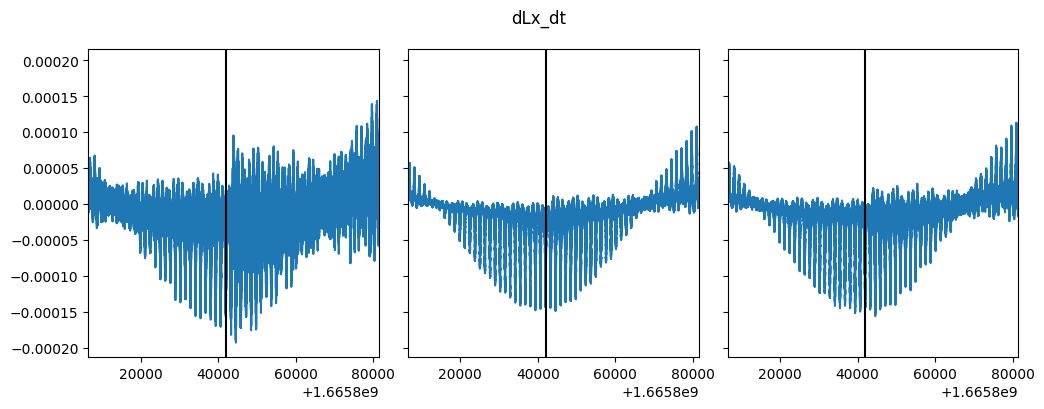

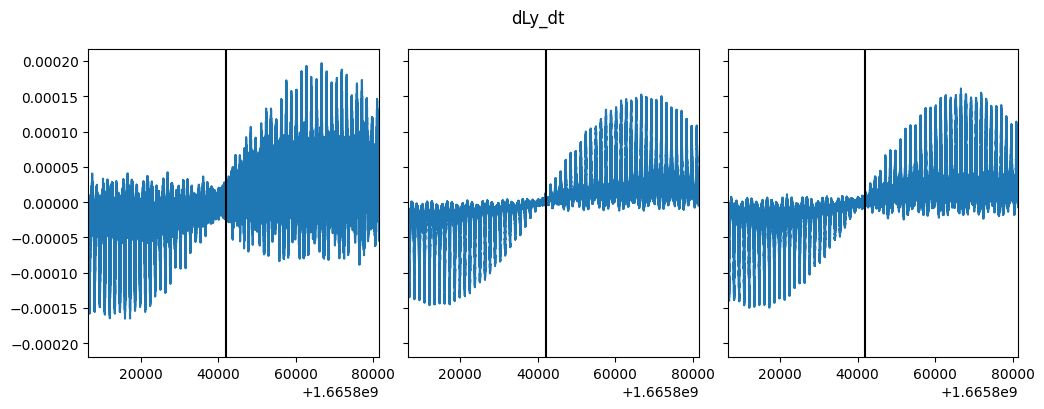

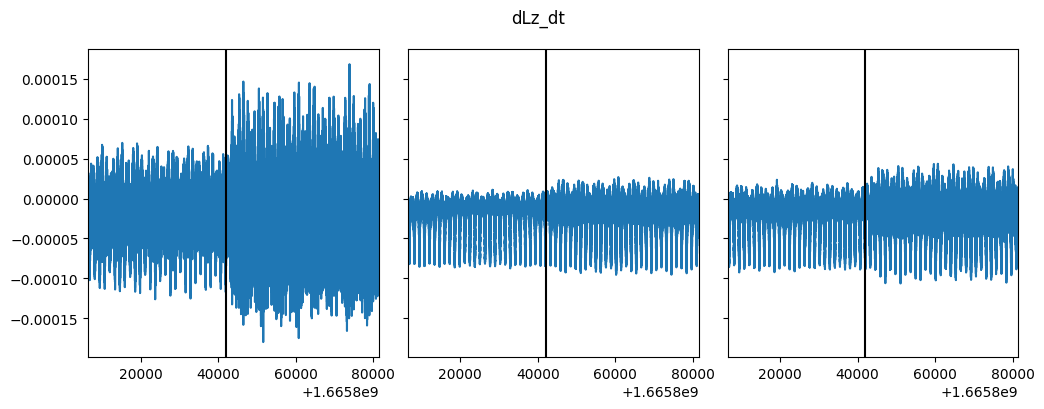

In [267]:

print(np.shape(coolquad_l))
print(np.shape(int_time_l))
print(np.shape(dt2_l))
print(np.shape(drv2_l))
print(np.shape(dd2_l))
print(np.shape(dt3_l))
print(np.shape(drv3_l))
print(np.shape(dd3_l))
print(np.shape(dldt_v3_l))

weird, tweak = 1.665842e9, 0.75
small_start, small_end = (1 - tweak)*start + tweak*weird, (1 - tweak)*end + tweak*weird

i = 0
plt.plot(0.5*(kink["time"][ixs[:-1]] + kink["time"][ixs[1:]]), d_cons[:,i])
plt.title(["dE", "dLx", "dLy", "dLz"][i])
plt.xlim(small_start, small_end)
plt.axvline(weird, c="k")
plt.show()
'''
for i in range(3):
    for j in range(i+1):
        plt.plot(int_time_l, quad_l[:, i, j])
        plt.title(f"quad {i}-{j}")
        plt.xlim(small_start, small_end)
        plt.axvline(weird, c="k")
        plt.show()
'''
for i in range(3):
    for j in range(i+1):
        plt.plot(int_time_l, coolquad_l[:, i, j])
        plt.title(f"coolquad {i}-{j}")
        plt.xlim(small_start, small_end)
        plt.axvline(weird, c="k")
        plt.show()

for i in range(3):
    for j in range(i+1):
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        fig.subplots_adjust(wspace=0.1)
        ax[0].plot(int_time_cut_l, dt2_l[:, i, j])
        ax[0].set_xlim(small_start, small_end)
        ax[0].axvline(weird, c="k")
        ax[1].plot(int_time_cut_l, drv2_l[:, i, j])
        ax[1].set_xlim(small_start, small_end)
        ax[1].axvline(weird, c="k")
        ax[2].plot(int_time_cut_l, dd2_l[:, i, j])
        ax[2].set_xlim(small_start, small_end)
        ax[2].axvline(weird, c="k")
        plt.suptitle(f"dt2 {i}-{j}")
        plt.show()

for i in range(3):
    for j in range(i+1):
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        fig.subplots_adjust(wspace=0.1)
        ax[0].plot(int_time_cut_l, dt3_l[:, i, j])
        ax[0].set_xlim(small_start, small_end)
        ax[0].axvline(weird, c="k")
        ax[1].plot(int_time_cut_l, drv3_l[:, i, j])
        ax[1].set_xlim(small_start, small_end)
        ax[1].axvline(weird, c="k")
        ax[2].plot(int_time_cut_l, dd3_l[:, i, j])
        ax[2].set_xlim(small_start, small_end)
        ax[2].axvline(weird, c="k")
        plt.suptitle(f"dt3 {i}-{j}")
        plt.show()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
fig.subplots_adjust(wspace=0.1)
ax[0].plot(int_time_cut_l, dedt_l)
ax[0].set_xlim(small_start, small_end)
ax[0].axvline(weird, c="k")
ax[1].plot(int_time_cut_l, dedt_v2_l)
ax[1].set_xlim(small_start, small_end)
ax[1].axvline(weird, c="k")
ax[2].plot(int_time_cut_l, dedt_v3_l)
ax[2].set_xlim(small_start, small_end)
ax[2].axvline(weird, c="k")
plt.suptitle(f"dedt")
plt.show()

for i in range(3):
    fig, ax = plt.subplots(1, 3, sharey=True, figsize=(12, 4))
    fig.subplots_adjust(wspace=0.1)
    ax[0].plot(int_time_cut_l, dldt_l[:, i])
    ax[0].set_xlim(small_start, small_end)
    ax[0].axvline(weird, c="k")
    ax[1].plot(int_time_cut_l, dldt_v2_l[:, i])
    ax[1].set_xlim(small_start, small_end)
    ax[1].axvline(weird, c="k")
    ax[2].plot(int_time_cut_l, dldt_v3_l[:, i])
    ax[2].set_xlim(small_start, small_end)
    ax[2].axvline(weird, c="k")
    plt.suptitle(["dLx_dt", "dLy_dt", "dLz_dt"][i])
    plt.show()

In [269]:
print(np.sum(dedt_l), np.sum(dedt_v2_l), np.sum(dedt_v3_l))
for i in range(3):
    print(np.sum(dldt_l[:,i]), np.sum(dldt_v2_l[:,i]), np.sum(dldt_v3_l[:,i]))

-1.5950054981264494 -0.8282663758295141 -0.8768723715598672
-5.3997586329474565 -5.39968145828516 -5.399755251119963
2.962302034193696 2.962239442546149 2.96226302397666
-50.89238071230785 -50.89214728071669 -50.89234682052341


Quick notes before I forget/leave! In trying to find the source of the weird kinky/bad behavior in my inspirals, I found that the issue at least *partially* has to do with how I'm calculating derivatives. I'm going to try and find a new inspiral that runs on a more workable timescale, run it with the different derivative schemes to see if it has a noticeable effect. More testing, weee.

In [2]:
import MetricMathStreamline as mm
import MainLoopStreamline as ml
import OrbitPlotter as op
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import importlib
from tqdm import tqdm
importlib.reload(ml)
importlib.reload(mm)
importlib.reload(op)

p, e, inc = 8, 0.25, 30*np.pi/180
p_stuff = [p/(1 - e**2), e, inc]
test = ml.EMRIGenerator(-0.8, 1e-3, params=p_stuff, label="Generic Inspiral (Paper)", err_target=1e-12)
g2002 = mm.glamp_2002(-0.8, 1e-7, params=p_stuff)
gg2006 = mm.gair_glamp_2006(-0.8, 1e-7, params=p_stuff)
p_sep, e_sep, _ = mm.get_sep_inc(-0.8, inc)


Normalizing initial state


10005566.327447519it [48:58, 3405.19it/s, Semilat: 7.783, Ecc 0.207, Peri: 6.45, Theta_min: 0.166*pi]                                  
  0%|          | 0/10000 [00:00<?, ?it/s, Semilat: 7.9999, Ecc 0.2500, Peri: 6.0000, dt=9.2159e+09]C:\Users\camcinto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\std.py:636: TqdmWarning: clamping frac to range [0, 1]
  full_bar = Bar(frac,
 -0%|          | -1/10000 [00:00<-1:46:10, -12.05it/s, Semilat: 7.9999, Ecc 0.2500, Peri: 6.0000, dt=9.6767e+09]C:\Users\camcinto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\std.py:636: TqdmWarning: clamping frac to range [0, 1]
  full_bar = Bar(frac,
 -0%|          | -1/10000 [00:00<-1:46:10, -12.05it/s, Semilat: 7.9999, Ecc 0.2500, Peri: 6.0000, dt=1.0161e+10]C:\Users\camcinto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0

Turning Point Complexity Exceeded Allowed Threshold


1188546it [00:00, 1188993.61it/s, Semilat: 7.6044, Ecc 0.2621, Peri: 5.6114, dt=1.0485e+10]                      

Turning Point Complexity Exceeded Allowed Threshold


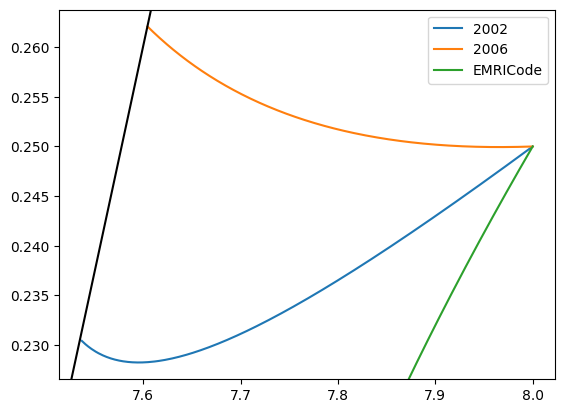

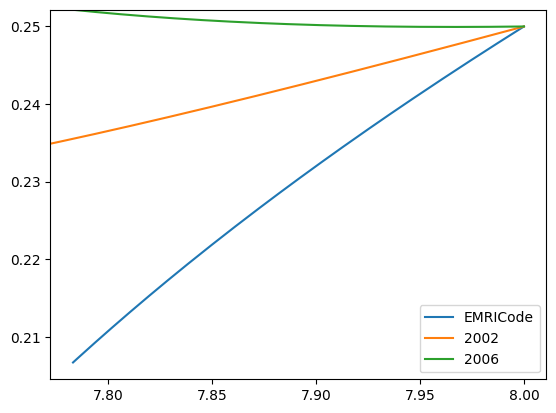

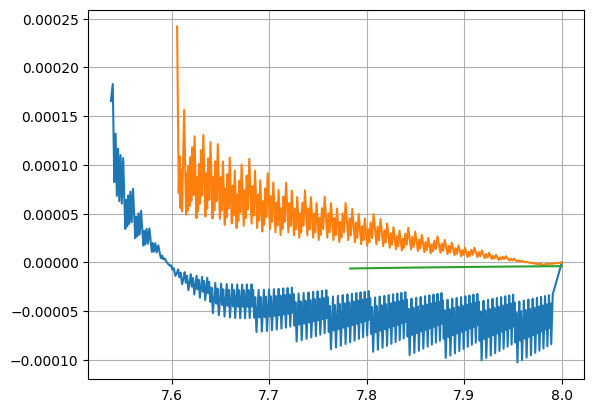

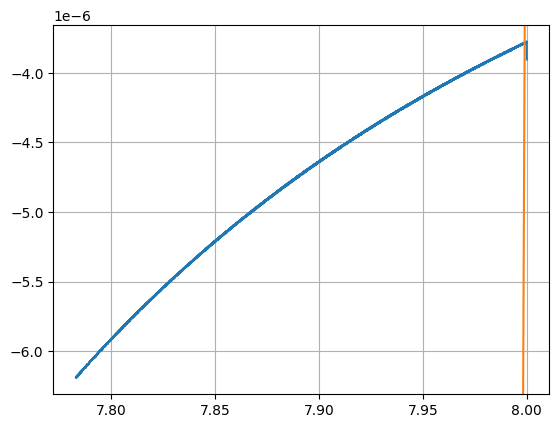

In [3]:

def do_derv(x, y):
    plt.plot(0.5*(x[:-1] + x[1:]), np.diff(y))

plt.plot(g2002["p"], g2002["e"], label="2002")
plt.plot(gg2006["p"], gg2006["e"], label="2006")
xlim, ylim = plt.xlim(), plt.ylim()
plt.plot(test["p"], test["e"], label="EMRICode")
plt.plot(p_sep, e_sep, c="k")
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()

plt.plot(test["p"], test["e"], label="EMRICode")
xlim, ylim = plt.xlim(), plt.ylim()
plt.plot(g2002["p"], g2002["e"], label="2002")
plt.plot(gg2006["p"], gg2006["e"], label="2006")

plt.plot(p_sep, e_sep, c="k")
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()


do_derv(g2002["p"], g2002["e"])
do_derv(gg2006["p"], gg2006["e"])
xlim, ylim = plt.xlim(), plt.ylim()
do_derv(test["p"], test["e"])
plt.xlim(xlim)
plt.ylim(ylim)
plt.grid()
plt.show()

do_derv(test["p"], test["e"])
xlim, ylim = plt.xlim(), plt.ylim()
do_derv(g2002["p"], g2002["e"])
do_derv(gg2006["p"], gg2006["e"])
plt.xlim(xlim)
plt.ylim(ylim)
plt.grid()
plt.show()

In [25]:
import MetricMathStreamline as mm
import MainLoopStreamline as ml
import OrbitPlotter as op
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import importlib
from tqdm import tqdm
importlib.reload(ml)
importlib.reload(mm)
importlib.reload(op)

p, e, inc = 7.8, 0.1, 30*np.pi/180
p_stuff = [p/(1 - e**2), e, inc]
test2_1 = ml.EMRIGenerator(-0.8, 1e-3, endflag="rad_orbit > 10000", params=p_stuff, label="Generic Inspiral (Paper)", err_target=1e-12)
test2_2 = ml.EMRIGenerator(-0.8, 1e-3, endflag="rad_orbit > 10000", params=p_stuff, label="Generic Inspiral (Paper) mark1", err_target=1e-12)
test2_3 = ml.EMRIGenerator(-0.8, 1e-3, endflag="rad_orbit > 10000", params=p_stuff, label="Generic Inspiral (Paper) mark2", err_target=1e-12)
g2002 = mm.glamp_2002(-0.8, 1e-8, params=p_stuff)
gg2006 = mm.gair_glamp_2006(-0.8, 1e-7, params=p_stuff)
p_sep, e_sep, _ = mm.get_sep_inc(-0.8, inc)

Normalizing initial state


 64%|██████▎   | 6372633.999999996/10000000 [28:39<17:49, 3390.22it/s, Semilat: 7.63, Ecc 0.001, Peri: 7.621, Theta_min: 0.166*pi]  

BADVALS 0.9523406093642487 1.8896525820421948 10.757023359991354

Ending program


 64%|██████▎   | 6372633.999999996/10000000 [28:40<16:19, 3703.76it/s, Semilat: 7.63, Ecc 0.001, Peri: 7.621, Theta_min: 0.166*pi]


Normalizing initial state


...

BADVALS 0.9523406079771759 1.8896525092331762 10.757022535756454

Ending program


 64%|██████▎   | 6372656.999999987/10000000 [28:14<16:04, 3761.15it/s, Semilat: 7.63, Ecc 0.001, Peri: 7.62, Theta_min: 0.166*pi]
  0%|          | 0/10000 [00:04<?, ?it/s, Semilat: 7.8000, Ecc 0.1000, Peri: 7.0909]

Turning Point Monotonic Descent Violated



244773it [00:01, 162622.90it/s, Semilat: 7.2842, Ecc 0.1181, Peri: 6.4236, dt=4.4567e+09]                        

Turning Point Complexity Exceeded Allowed Threshold


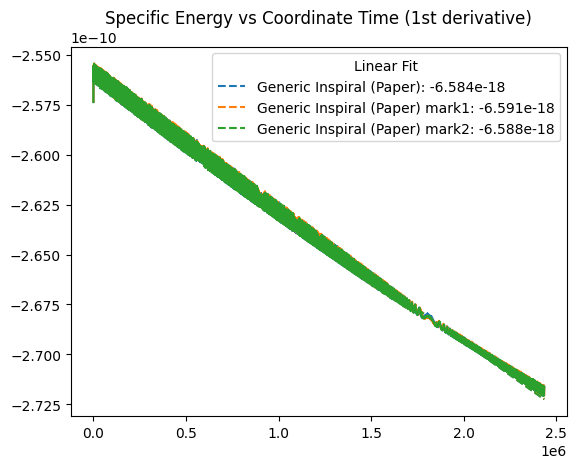

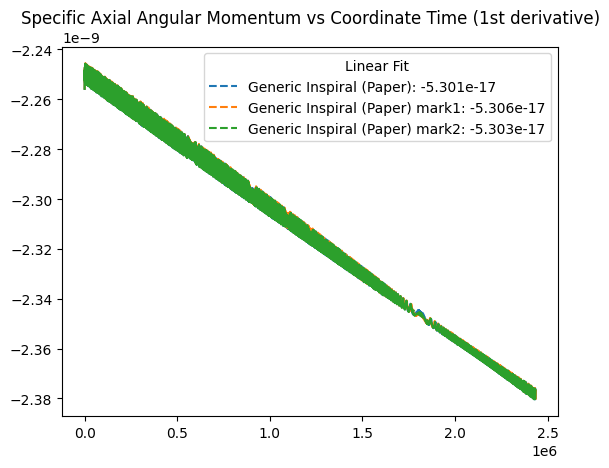

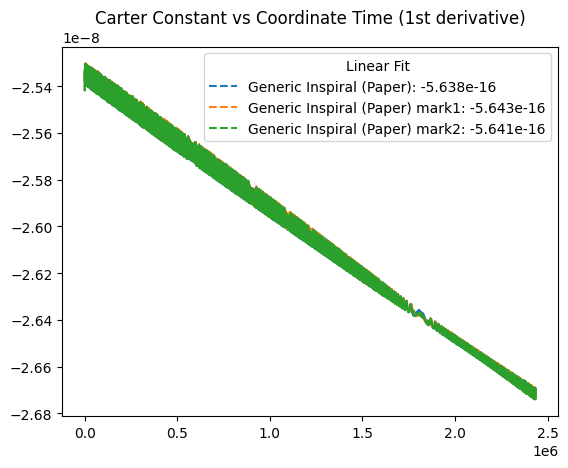

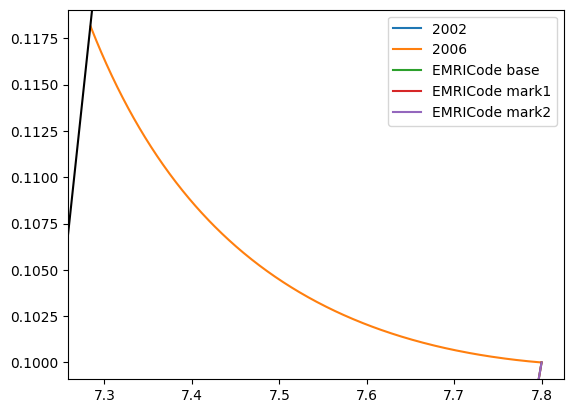

[   1.76990569  -41.87930319  330.54918434 -870.15911928]


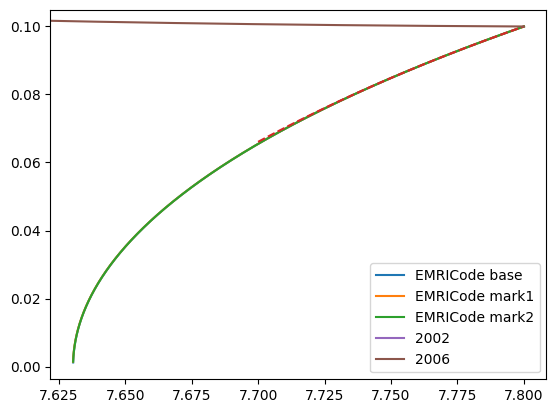

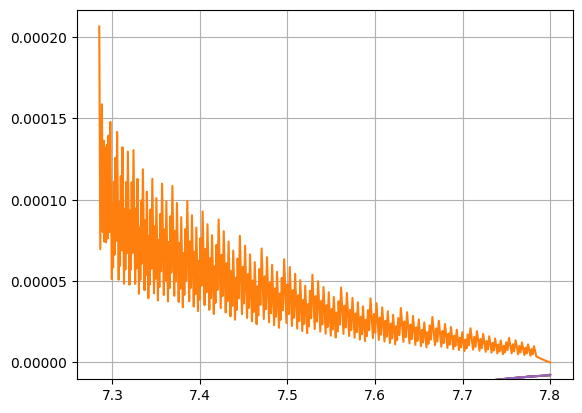

[ 0.00228073 -0.05344238  0.41745696 -1.08706229]


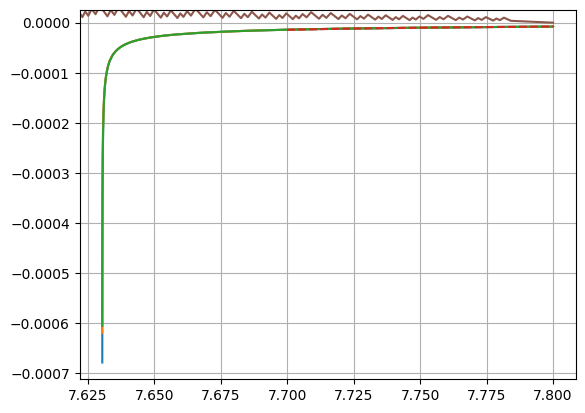

[-1.02833561e-05  2.39148929e-04 -1.85382932e-03  4.79003391e-03]


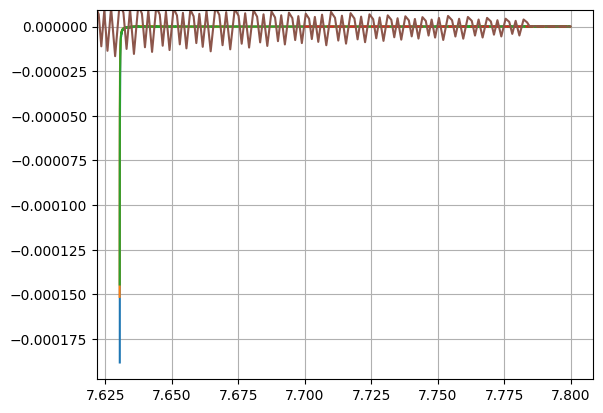

In [30]:

def do_derv(x, y):
    return 0.5*(x[:-1] + x[1:]), np.diff(y)

op.plotvalue3([test2_1, test2_2, test2_3], "tracktime", "energy", derv=1)
op.plotvalue3([test2_1, test2_2, test2_3], "tracktime", "L_z", derv=1)
op.plotvalue3([test2_1, test2_2, test2_3], "tracktime", "carter", derv=1)

plt.plot(g2002["p"], g2002["e"], label="2002")
plt.plot(gg2006["p"], gg2006["e"], label="2006")
xlim, ylim = plt.xlim(), plt.ylim()
plt.plot(test2_1["p"], test2_1["e"], label="EMRICode base")
plt.plot(test2_2["p"], test2_2["e"], label="EMRICode mark1")
plt.plot(test2_3["p"], test2_3["e"], label="EMRICode mark2")
plt.plot(p_sep, e_sep, c="k")
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()

m = 7.7

plt.plot(test2_1["p"], test2_1["e"], label="EMRICode base")
plt.plot(test2_2["p"], test2_2["e"], label="EMRICode mark1")
plt.plot(test2_3["p"], test2_3["e"], label="EMRICode mark2")
p = np.polyfit(test2["p"][5:], test2["e"][5:], 3)
print(p)
plt.plot(np.linspace(m, test2["p"].max()), np.polyval(p, np.linspace(m, test2["p"].max())), linestyle="--")
xlim, ylim = plt.xlim(), plt.ylim()
plt.plot(g2002["p"], g2002["e"], label="2002")
plt.plot(gg2006["p"], gg2006["e"], label="2006")

plt.plot(p_sep, e_sep, c="k")
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()


plt.plot(*do_derv(g2002["p"], g2002["e"]))
plt.plot(*do_derv(gg2006["p"], gg2006["e"]))
xlim, ylim = plt.xlim(), plt.ylim()
plt.plot(*do_derv(test2_1["p"], test2_1["e"]), label="EMRi base")
plt.plot(*do_derv(test2_2["p"], test2_2["e"]), label="EMRi mark1")
plt.plot(*do_derv(test2_3["p"], test2_3["e"]), label="EMRi mark2")
plt.xlim(xlim)
plt.ylim(ylim)
plt.grid()
plt.show()

plt.plot(*do_derv(test2_1["p"], test2_1["e"]), label="EMRi base")
plt.plot(*do_derv(test2_2["p"], test2_2["e"]), label="EMRi mark1")
plt.plot(*do_derv(test2_3["p"], test2_3["e"]), label="EMRi mark2")
p = np.polyfit(*do_derv(test2["p"], test2["e"]), 3)
print(p)
plt.plot(np.linspace(m, test2["p"].max()), np.polyval(p, np.linspace(m, test2["p"].max())), linestyle="--")
xlim, ylim = plt.xlim(), plt.ylim()
plt.plot(*do_derv(g2002["p"], g2002["e"]))
plt.plot(*do_derv(gg2006["p"], gg2006["e"]))
plt.xlim(xlim)
plt.ylim(ylim)
plt.grid()
plt.show()

plt.plot(*do_derv(*do_derv(test2_1["p"][5:], test2_1["e"][5:])), label="EMRi base")
plt.plot(*do_derv(*do_derv(test2_2["p"][5:], test2_2["e"][5:])), label="EMRi mark1")
plt.plot(*do_derv(*do_derv(test2_3["p"][5:], test2_3["e"][5:])), label="EMRi mark2")
p = np.polyfit(*do_derv(*do_derv(test2["p"][5:], test2["e"][5:])), 3)
print(p)
plt.plot(np.linspace(m, test2["p"].max()), np.polyval(p, np.linspace(m, test2["p"].max())), linestyle="--")
xlim, ylim = plt.xlim(), plt.ylim()
plt.plot(*do_derv(*do_derv(g2002["p"][5:], g2002["e"][5:])))
plt.plot(*do_derv(*do_derv(gg2006["p"][5:], gg2006["e"][5:])))
plt.xlim(xlim)
plt.ylim(ylim)
plt.grid()
plt.show()

In [ ]:
import emri_worker as ew
from multiprocessing import Process
import os

def main():
    inspiral_strs = [
        'ml.EMRIGenerator(-0.8, 1e-3, params=[8/(1 - (0.25)**2), 0.25, 30*np.pi/180], label="Close Test mark0", err_target=1e-12, verbose=0, force_stop=should_stop)',
        'ml.EMRIGenerator(-0.8, 1e-3, params=[8/(1 - (0.25)**2), 0.25, 30*np.pi/180], label="Close Test mark1", err_target=1e-12, verbose=0, force_stop=should_stop)',
        'ml.EMRIGenerator(-0.8, 1e-3, params=[8/(1 - (0.25)**2), 0.25, 30*np.pi/180], label="Close Test mark2", err_target=1e-12, verbose=0, force_stop=should_stop)'
    ]

    # stagger write poll intervals to avoid simultaneous writes
    polls = np.random.uniform(0.5, 6, len(inspiral_strs))
    polls = np.cumsum(polls)

    print("Preparing workers.", flush=True)

    max_workers = min(len(inspiral_strs), os.cpu_count() - 1)

    processes = []
    for s, p in zip(inspiral_strs, polls):
        proc = Process(target=ew.run_single_inspiral, args=(s, p, 30.0))
        processes.append(proc)
        proc.start()

    print(len(processes), "woo")

    try:
        for proc in processes:
            proc.join()
    except KeyboardInterrupt:
        for proc in processes:
            proc.join()

if __name__ == "__main__":
    main()

Preparing workers.


3 woo


In [4]:
import MetricMathStreamline as mm
import MainLoopStreamline as ml
import OrbitPlotter as op
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import importlib
from tqdm import tqdm
importlib.reload(ml)
importlib.reload(mm)
importlib.reload(op)

gorf = ml.load_index()
lst = [filename for filename, dat in gorf.items() if "Close Test" in dat["Label"]]
print(lst)
for thing in lst:
    ml.delete_emri_data(thing, auto=True)
lst = [filename for filename, dat in gorf.items() if "Close Test" in dat["Label"]]
print(lst)

['auto_eebf_a2.h5', 'auto_eebf_a2_1.h5', 'auto_eebf_a3.h5', 'auto_eebf_c1.h5', 'auto_eebf_c1_1.h5', 'auto_eebf_c1_2.h5', 'auto_eebf_df.h5', 'auto_eebf_e0.h5', 'auto_eebf_e0_1.h5', 'auto_eebf_fc.h5', 'auto_eebf_ff.h5', 'auto_eebf_ff_1.h5']
Deleted file: D:/EMRIData/saved_sims/auto_eebf_a2.h5
Removed auto_eebf_a2.h5 from index.
Deleted file: D:/EMRIData/saved_sims/auto_eebf_a2_1.h5
Removed auto_eebf_a2_1.h5 from index.
Deleted file: D:/EMRIData/saved_sims/auto_eebf_a3.h5
Removed auto_eebf_a3.h5 from index.
Deleted file: D:/EMRIData/saved_sims/auto_eebf_c1.h5
Removed auto_eebf_c1.h5 from index.
Deleted file: D:/EMRIData/saved_sims/auto_eebf_c1_1.h5
Removed auto_eebf_c1_1.h5 from index.
Deleted file: D:/EMRIData/saved_sims/auto_eebf_c1_2.h5
Removed auto_eebf_c1_2.h5 from index.
Deleted file: D:/EMRIData/saved_sims/auto_eebf_df.h5
Removed auto_eebf_df.h5 from index.
Deleted file: D:/EMRIData/saved_sims/auto_eebf_e0.h5
Removed auto_eebf_e0.h5 from index.
Deleted file: D:/EMRIData/saved_sims/